<a href="https://colab.research.google.com/github/mahoneyjustinnj/myGarminHealth_JM/blob/main/analyzingGarminHeartDataColab.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
# from google.colab import ai
# response = ai.generate_text("What is the capital of France?")

In [6]:
#$$
# suppressMessages(install.packages("tidyverse"))
# suppressMessages(install.packages("lubridate"))
# suppressMessages(install.packages("FSA"))
# suppressMessages(install.packages("RColorBrewer"))
# suppressMessages(install.packages("dplyr"))
# suppressMessages(install.packages("plotly"))
# suppressMessages(install.packages("ggplot2"))
# suppressMessages(install.packages("ggpubr"))
# suppressMessages(install.packages("skimr"))
# suppressMessages(install.packages("tibble"))
# suppressMessages(install.packages("htmltools"))
# suppressMessages(install.packages("tibbletime"))
# suppressMessages(install.packages("zoo"))
# suppressMessages(install.packages("tidyr"))
# suppressMessages(install.packages("anomalize"))
# suppressMessages(install.packages("knitr"))
# suppressMessages(install.packages("gt"))
# suppressMessages(install.packages("stringr"))
# suppressMessages(install.packages("grid"))
#$$
# Suppress package installation messages
suppressMessages(suppressWarnings({
  library(tidyverse)       # Data manipulation and visualization (includes dplyr, ggplot2, etc.)
  library(lubridate)       # Date and time manipulation functions
  library(FSA)             # Fisheries Stock Assessment - includes statistical tests like Dunn's test
  library(RColorBrewer)    # Color palettes for plots
  library(dplyr)           # Data frame manipulation (part of tidyverse, loaded explicitly for clarity)
  library(plotly)          # Interactive plotting library
  library(ggplot2)         # Static plotting (part of tidyverse, loaded explicitly)
  library(ggpubr)          # Publication-ready ggplot2 figures
  library(skimr)           # Quick data summary function
  library(tibble)          # Modern data frame format
  library(htmltools)       # HTML utilities for Shiny/markdown
  library(tibbletime)      # Time-aware tibbles for time series
  library(zoo)             # Time series and irregular data handling (includes na.approx)
  library(tidyr)           # Data reshaping (pivot_wider, unnest, etc.)
  library(anomalize)       # Time series anomaly detection
  library(knitr)           # R Markdown processing
  library(gt)              # Great Tables - nice table formatting
  library(stringr)         # String manipulation functions
  library(grid)            # Low-level graphics utilities
}))
#$$
knitr::opts_chunk$set(
  warning = FALSE,    # Suppress warning messages during knitting
  message = FALSE     # Suppress informational messages during knitting
)

In [7]:
#$$
# cat("\014")  # Clear console (commented out)
gc()                                                    # Garbage collection - free up memory

rm(list = ls())                                         # Remove all objects from environment

setwd("/content")

,used,(Mb),gc trigger,(Mb),max used,(Mb)
Ncells,1474605,78.8,2501942,133.7,2501942,133.7
Vcells,2560799,19.6,8388608,64.0,8388608,64.0


In [8]:
# Don't use vroom or tidyverse - just base R
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

file_path <- "garmin_combined_summaries_from_2026-01-05.csv"

# Read just the header (first row)
header <- read.csv(file_path, nrows = 1, stringsAsFactors = FALSE)

cat("=== FILE DIAGNOSTICS ===\n")
cat("Total columns:", ncol(header), "\n")
cat("Total column name characters:", sum(nchar(colnames(header))), "\n\n")

# Find duplicate column names
col_freq <- table(colnames(header))
duplicates <- names(col_freq[col_freq > 1])

cat("Duplicate columns found:", length(duplicates), "\n")
if(length(duplicates) > 0) {
  cat("\nDuplicate column names and their frequencies:\n")
  print(col_freq[col_freq > 1])
}

# Show first 20 column names
cat("\n\nFirst 20 column names:\n")
print(colnames(header)[1:20])

# Show last 20 column names
cat("\n\nLast 20 column names:\n")
print(colnames(header)[(ncol(header)-19):ncol(header)])

=== FILE DIAGNOSTICS ===
Total columns: 53 
Total column name characters: 1074 

Duplicate columns found: 0 


First 20 column names:
 [1] "summaryDate"                      "userProfilePK"                   
 [3] "calendarDate"                     "startTimestampGMT"               
 [5] "endTimestampGMT"                  "startTimestampLocal"             
 [7] "endTimestampLocal"                "maxHeartRate"                    
 [9] "minHeartRate"                     "restingHeartRate"                
[11] "lastSevenDaysAvgRestingHeartRate" "heartRateValues"                 
[13] "heartRateValueDescriptors"        "userProfilePk"                   
[15] "hrvSummary"                       "hrvReadings"                     
[17] "sleepStartTimestampGMT"           "sleepEndTimestampGMT"            
[19] "sleepStartTimestampLocal"         "sleepEndTimestampLocal"          


Last 20 column names:
 [1] "respirationVersion"                  
 [2] "dailySleepDTO"                       
 [3]

In [9]:
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

# file_path <- "garmin_combined_summaries_from_2026-01-02.csv"

# # Read with base R
# data <- read.csv(file_path, stringsAsFactors = FALSE)

# cat("File loaded successfully!\n")
# cat("Dimensions:", nrow(data), "rows x", ncol(data), "columns\n")
# cat("Column names:\n")
# print(colnames(data))

# # Preview first row
# cat("\n\nFirst row preview:\n")
# str(data[1, ])

In [10]:
# # Select just the health metrics you need
# health_data <- data.frame(
#   date = data$calendarDate,
#   max_hr = data$maxHeartRate,
#   min_hr = data$minHeartRate,
#   resting_hr = data$restingHeartRate,
#   sleep_start = data$sleepStartTimestampLocal,
#   sleep_end = data$sleepEndTimestampLocal,
#   hrv_summary = data$hrvSummary,
#   sleep_heart_rate = data$sleepHeartRate,
#   sleep_stress = data$sleepStress,
#   sleep_body_battery = data$sleepBodyBattery
# )

# head(health_data)

##This reads in the data

In [11]:
Sys.setenv("VROOM_CONNECTION_SIZE" = 5000000)

needed_cols <- c(
  # Dates
  "calendarDate", "summaryDate",
  # Heart Rate
  "heartRateValues", "heartRateValueDescriptors",
  "maxHeartRate", "minHeartRate", "restingHeartRate", "lastSevenDaysAvgRestingHeartRate",
  # HRV
  "userProfilePK", "userProfilePk",
  "startTimestampGMT", "endTimestampGMT", "startTimestampLocal", "endTimestampLocal",
  "hrvSummary", "hrvReadings",
  # Sleep
  "sleepStartTimestampGMT", "sleepEndTimestampGMT",
  "sleepStartTimestampLocal", "sleepEndTimestampLocal",
  "tomorrowSleepStartTimestampGMT", "tomorrowSleepEndTimestampGMT",
  "tomorrowSleepStartTimestampLocal", "tomorrowSleepEndTimestampLocal",
  # Respiration
  "lowestRespirationValue", "highestRespirationValue",
  "avgWakingRespirationValue", "avgSleepRespirationValue", "avgTomorrowSleepRespirationValue"
)

df_raw <- read.csv("garmin_combined_summaries_from_2026-01-05.csv",
                    colClasses = "character")

# Keep only needed columns
df <- df_raw[, intersect(colnames(df_raw), needed_cols)]

cat("Loaded:", nrow(df), "rows x", ncol(df), "columns\n")
head(df)

Loaded: 139 rows x 29 columns


,summaryDate,userProfilePK,calendarDate,startTimestampGMT,endTimestampGMT,startTimestampLocal,endTimestampLocal,maxHeartRate,minHeartRate,restingHeartRate,⋯,sleepEndTimestampLocal,tomorrowSleepStartTimestampGMT,tomorrowSleepEndTimestampGMT,tomorrowSleepStartTimestampLocal,tomorrowSleepEndTimestampLocal,lowestRespirationValue,highestRespirationValue,avgWakingRespirationValue,avgSleepRespirationValue,avgTomorrowSleepRespirationValue
,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>
1,2025-08-20,136631288,2025-08-20,2025-08-20T04:00:00.0,2025-08-21T04:00:00.0,2025-08-20T00:00:00.0,2025-08-21T00:00:00.0,,,52,⋯,2025-08-20T07:44:40.0,2025-08-21T04:38:17.0,2025-08-21T11:40:17.0,2025-08-21T00:38:17.0,2025-08-21T07:40:17.0,7.0,24.0,16.0,13.0,17.0
2,2025-08-21,136631288,2025-08-21,2025-08-21T04:00:00.0,2025-08-22T04:00:00.0,2025-08-21T00:00:00.0,2025-08-22T00:00:00.0,,,59,⋯,2025-08-21T07:40:17.0,2025-08-22T04:54:54.0,2025-08-22T11:36:16.0,2025-08-22T00:54:54.0,2025-08-22T07:36:16.0,7.0,24.0,17.0,17.0,16.0
3,2025-08-22,136631288,2025-08-22,2025-08-22T04:00:00.0,2025-08-23T04:00:00.0,2025-08-22T00:00:00.0,2025-08-23T00:00:00.0,,,52,⋯,2025-08-22T07:36:16.0,2025-08-23T04:38:11.0,2025-08-23T12:39:11.0,2025-08-23T00:38:11.0,2025-08-23T08:39:11.0,9.0,25.0,17.0,16.0,15.0
4,2025-08-23,136631288,2025-08-23,2025-08-23T04:00:00.0,2025-08-24T04:00:00.0,2025-08-23T00:00:00.0,2025-08-24T00:00:00.0,,,56,⋯,2025-08-23T08:39:11.0,2025-08-24T05:10:39.0,2025-08-24T11:55:39.0,2025-08-24T01:10:39.0,2025-08-24T07:55:39.0,7.0,24.0,18.0,15.0,16.0
5,2025-08-24,136631288,2025-08-24,2025-08-24T04:00:00.0,2025-08-25T04:00:00.0,2025-08-24T00:00:00.0,2025-08-25T00:00:00.0,,,58,⋯,2025-08-24T07:55:39.0,2025-08-25T04:52:18.0,2025-08-25T10:18:18.0,2025-08-25T00:52:18.0,2025-08-25T06:18:18.0,9.0,25.0,18.0,16.0,16.0
6,2025-08-25,136631288,2025-08-25,2025-08-25T04:00:00.0,2025-08-26T04:00:00.0,2025-08-25T00:00:00.0,2025-08-26T00:00:00.0,,,54,⋯,2025-08-25T06:18:18.0,2025-08-26T03:54:29.0,2025-08-26T09:47:43.0,2025-08-25T23:54:29.0,2025-08-26T05:47:43.0,8.0,24.0,17.0,16.0,15.0


##This creates the functions

In [12]:
#$$
# df_raw <- read_csv("garmin_combined_summaries_from_2026-01-02.csv")
# df <- df_raw
# Display first n rows of dataframe with gt styling and header
show_tb <- function(df, n = 6) {
  library(gt)

  df %>%
    head(n) %>%                          # Get first n rows
    gt() %>%                             # Convert to gt table object
    tab_header(
      title = paste("Showing First", n, "Rows"),      # Add title with dynamic row count
      subtitle = "Styled with gt"                      # Add subtitle
    )
}
#$$
# Track dataframes and their columns in all_names data structure
fx <- function(...  ) {
  arg_exprs <- substitute(list(...))[-1]  # Capture unevaluated arguments as expressions
  i <- 1                                   # Initialize loop counter

  while (i <= length(arg_exprs)) {
    expr <- arg_exprs[[i]]                 # Get current expression
    is_comment <- FALSE                    # Flag for comment detection (unused)

    # Skip comment-only arguments
    if (is.character(expr)) {
      i <- i + 1
      next                                 # Move to next iteration if argument is character string
    }

    df_name <- deparse(expr)               # Convert expression to character string (dataframe name)
    comment <- ""                          # Initialize comment variable

    # Check if next argument is a comment string
    if (i < length(arg_exprs) && is.character(arg_exprs[[i + 1]])) {
      comment <- eval(arg_exprs[[i + 1]], envir = .GlobalEnv)  # Evaluate next arg as comment
      i <- i + 1                           # Skip the comment in next iteration
    }

    # Evaluate dataframe existence and get column names
    df_exists <- exists(df_name, envir = .GlobalEnv)  # Check if dataframe exists in global environment
    if (df_exists) {
      df <- get(df_name, envir = .GlobalEnv)         # Retrieve the dataframe object
      if (!inherits(df, "data.frame")) {
        message(df_name, " exists but is not a dataframe.   Skipping.")
        i <- i + 1
        next                               # Skip if not a dataframe
      }
      col_list <- paste(names(df), collapse = ", ")  # Get all column names as comma-separated string
    } else {
      col_list <- ""                       # Empty string if dataframe doesn't exist
      comment <- paste0("object '", df_name, "' not found\n", comment)  # Add error message to comment
      message(df_name, " is not present in environment but added to all_names.")
    }

    # Add or update entry in tracking dataframe
    idx <- which(all_names$dataframe == df_name)     # Find if dataframe already tracked
    if (length(idx) == 1) {
      if (comment != "") {
        all_names$comment[idx] <<- paste(all_names$comment[idx], comment, sep = "\n")  # Append comment
      }
      if (col_list != "") {
        all_names$columns[idx] <<- col_list          # Update columns if not empty
      }
    } else {
      all_names <<- rbind(
        all_names,
        data.frame(dataframe = df_name, columns = col_list, comment = comment, stringsAsFactors = FALSE)
      )                                    # Add new row to all_names tracking table
    }

    i <- i + 1                             # Increment counter
  }

  # Reorder:  move rows with empty columns to bottom
  empty_rows <- which(all_names$columns == "")       # Find rows with no columns (missing dataframes)
  filled_rows <- which(all_names$columns != "")      # Find rows with columns (existing dataframes)
  all_names <<- all_names[c(filled_rows, empty_rows), ]  # Reorder:  existing first, missing last
}

#$$
# Compare column names between dataframes
comp_cols <- function(df_raw, ..., reverse = FALSE) {
  # Capture exclusions as character strings
  exclude <- as.character(substitute(list(... )))[-1]

  # Get column names from df_raw
  df_names <- names(df_raw)

  # Filter all_names based on exclude list
  if (length(exclude) > 0) {
    all_names_filtered <- all_names[!(all_names[[1]] %in% exclude), ]
  } else {
    all_names_filtered <- all_names
  }

  # Parse and clean all comma-separated column names
  ref_names <- unlist(strsplit(paste(all_names_filtered[[2]], collapse = ","), ","))
  ref_names_clean <- trimws(ref_names)

  # Return either missing or extra columns based on reverse flag
  if (reverse) {
    return(ref_names_clean[!(ref_names_clean %in% df_names)])
  } else {
    return(df_names[!(df_names %in% ref_names_clean)])
  }
}

#$$
# Initialize empty tracking dataframe
all_names <- data.frame(
  dataframe = character(0),
  columns = character(0),
  comment = character(0),
  stringsAsFactors = FALSE
)

#$$
# Add or append comment to tracked dataframe
add_comment <- function(df, comment) {
  # Convert dataframe argument to string to get its name
  df_name <- deparse(substitute(df))

  # Search all_names for row matching the dataframe name
  idx <- which(all_names$dataframe == df_name)

  # If dataframe found in all_names (should be exactly one match)
  if (length(idx) == 1) {
    # Check if comment field is currently empty
    if (all_names$comment[idx] == "") {
      # If empty, assign comment directly to the dataframe row
      all_names$comment[idx] <<- comment
    } else {
      # If comment already exists, append new comment with newline separator
      all_names$comment[idx] <<- paste(all_names$comment[idx], comment, sep = "\n")
    }
  }
}
#$$
# Clear all tracked dataframes in all_names
reset_fx <- function() {
  # Reassign all_names to empty dataframe with same structure
  all_names <<- data.frame(
    dataframe = character(0),  # Empty character vector for dataframe names
    columns = character(0),    # Empty character vector for column lists
    comment = character(0),    # Empty character vector for comments
    stringsAsFactors = FALSE   # Prevent automatic conversion of strings to factors
  )
}

#$$
# Display comments for a specific dataframe
df_comms <- function(df) {
  # Convert dataframe argument to string to get its name
  df_name <- deparse(substitute(df))

  # Search all_names for row matching the dataframe name
  idx <- which(all_names$dataframe == df_name)

  # If dataframe not found in all_names or comment field is empty
  if (length(idx) == 0 || all_names$comment[idx] == "") {
    # Print message indicating no comments exist for this dataframe
    message("There are no comments currently for this dataframe.")
  } else {
    # If comments exist, print them to console
    cat(all_names$comment[idx])
  }
}

#$$
# List all current dataframe objects in environment
curr_df <- function(env = .GlobalEnv) {
  # Get list of all object names in the specified environment
  objs <- ls(envir = env)

  # Filter objects to keep only those that are dataframes or dataframe-like objects
  df_objs <- Filter(function(x) {
    # Retrieve object from environment
    obj <- get(x, envir = env)

    # Check if object inherits from data.frame, tbl_df, or data.table classes
    inherits(obj, c("data.frame", "tbl_df", "data.table"))
  }, objs)

  # If no dataframes found in environment
  if (length(df_objs) == 0) {
    # Print message indicating no data-holding objects were found
    message("No data-holding objects found.")
  } else {
    # If dataframes found, print their names to console
    print(df_objs)
  }
}

#$$
# Find untracked dataframes in environment
misd_df <- function() {
  # Get current data-holding objects from environment
  current_dfs <- curr_df()

  # If no dataframes exist, return invisibly without printing anything
  if (is.null(current_dfs)) return(invisible(NULL))

  # Get list of already tracked dataframes from all_names
  tracked_dfs <- all_names$dataframe

  # Find dataframes that exist but are not in all_names (untracked)
  missing <- setdiff(current_dfs, tracked_dfs)

  # If all dataframes are already tracked
  if (length(missing) == 0) {
    # Print message indicating all dataframes are tracked
    message("All current dataframes are already tracked in all_names.")
  } else {
    # If untracked dataframes found, print header message
    cat("Untracked dataframes:\n")

    # Print list of untracked dataframes
    print(missing)
  }
}

In [13]:

# options(width = 200)  # Increase console width
# head(df)
# Set options to show all columns
options(width = 300, max.print = 10000)

# Use glimpse() with explicit width
library(dplyr)
glimpse(df, width = 500)

Rows: 139
Columns: 29
$ summaryDate                      <chr> "2025-08-20", "2025-08-21", "2025-08-22", "2025-08-23", "2025-08-24", "2025-08-25", "2025-08-26", "2025-08-27", "2025-08-28", "2025-08-29", "2025-08-30", "2025-08-31", "2025-09-01", "2025-09-02", "2025-09-03", "2025-09-04", "2025-09-05", "2025-09-06", "2025-09-07", "2025-09-08", "2025-09-09", "2025-09-10", "2025-09-11", "2025-09-12", "2025-09-13", "2025-09-14", "2025-09-15", "2025-09-16", "2025-09-17", "2025-09-18", "2025-09-19", "2025-09-20", "2025-09-…
$ userProfilePK                    <chr> "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "1366312

In [14]:

# options(width = 200)  # Increase console width
# head(df)
# Set options to show all columns
options(width = 300, max.print = 10000)

# Use glimpse() with explicit width
library(dplyr)
glimpse(df, width = 500)

Rows: 139
Columns: 29
$ summaryDate                      <chr> "2025-08-20", "2025-08-21", "2025-08-22", "2025-08-23", "2025-08-24", "2025-08-25", "2025-08-26", "2025-08-27", "2025-08-28", "2025-08-29", "2025-08-30", "2025-08-31", "2025-09-01", "2025-09-02", "2025-09-03", "2025-09-04", "2025-09-05", "2025-09-06", "2025-09-07", "2025-09-08", "2025-09-09", "2025-09-10", "2025-09-11", "2025-09-12", "2025-09-13", "2025-09-14", "2025-09-15", "2025-09-16", "2025-09-17", "2025-09-18", "2025-09-19", "2025-09-20", "2025-09-…
$ userProfilePK                    <chr> "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "136631288", "1366312

In [15]:
#$$
# Extract calendar date and heart rate values columns
dtwp <- df %>%
  select(calendarDate, heartRateValues)

dtwp <- dtwp %>%
  mutate(
    heartRateValues = ifelse(heartRateValues == "", "[]", heartRateValues),
    heartRateValues = trimws(heartRateValues)
  )

fx(dtwp, "takes these 2 columns from df - CLEANED")

de <- df %>%
  select(-heartRateValues, -heartRateValueDescriptors)

fx(de, "de takes everything from df except heartRateValues and heartRateValueDescriptors")

#$$
dtwp1 <- dtwp %>%
  mutate(heartRateValues = map(heartRateValues, ~ {
    tryCatch({
      .x <- gsub("None", "null", .x)
      parsed_data <- jsonlite::fromJSON(.x)
      return(parsed_data)
    }, error = function(e) {
      message(paste("Warning:  Failed to parse JSON"))
      return(data.frame(timestamp = numeric(0), heartrate = numeric(0)))
    })
  }))

fx(dtwp1, "dtwp1 parses JSON - WITH ERROR HANDLING")

#$$
dtwp2 <- dtwp1 %>%
  {
    rows_list <- list()
    for (i in seq_len(nrow(.  ))) {
      parsed <- . [[i, "heartRateValues"]]

      if (is.null(parsed) || length(parsed) == 0) {
        next
      } else if (is.matrix(parsed)) {
        df_temp <- as.data.frame(parsed)
        colnames(df_temp) <- c("seconds", "heartrate")
        df_temp$calendarDate <- . [[i, "calendarDate"]]
        rows_list[[i]] <- df_temp
      }
    }

    bind_rows(rows_list)
  }

fx(dtwp2, "dtwp2 extracts heartRateValues from matrix format")

#$$
data <- dtwp2 %>%
  mutate(
    time = as.POSIXct(seconds / 1000, origin = "1970-01-01", tz = "UTC"),
    time = with_tz(time, tzone = "America/Toronto"),
    heartrate = na.approx(heartrate, na.rm = FALSE)
  ) %>%
  select(calendarDate, time, heartrate)

fx(data, "data converted timestamps to Eastern Time")

#$$
#show_tb(data, 10)

#$$
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-05 
Total rows: 88723 


In [16]:
print("done to here")

[1] "done to here"


# done to here

In [17]:
head(data)

,calendarDate,time,heartrate
,<chr>,<dttm>,<dbl>
1,2025-09-01,2025-08-31 23:00:00,75
2,2025-09-01,2025-08-31 23:02:00,71
3,2025-09-01,2025-08-31 23:04:00,80
4,2025-09-01,2025-08-31 23:06:00,73
5,2025-09-01,2025-08-31 23:08:00,75
6,2025-09-01,2025-08-31 23:10:00,70


In [18]:
#$$
# data already created from dtwp2 with columns: calendarDate, time, heartrate
# Just rename and reorder columns for clarity

data <- data %>%
  rename(
    date = calendarDate
  ) %>%
  select(date, time, heartrate)

# Track data dataframe with description
fx(data, "data renamed and reordered columns:  date, time, heartrate")

#$$
# Display first few rows of processed data
#show_tb(data, 10)



In [19]:
#$$
# Check the date range in your data
#$$
# Check the date range in your data
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-05 
Total rows: 88723 


In [20]:

#$$
# Display first few rows of processed data
# show_tb(data, 1)
#$$
# Check the date range in your data
cat("Data date range:\n")
cat("Min date:", format(min(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Max date:", format(max(data$time, na.rm = TRUE), "%Y-%m-%d"), "\n")
cat("Total rows:", nrow(data), "\n")
#$$
# Extract daily heart rate statistics from de dataframe
de1 <- de %>% select(calendarDate, maxHeartRate, minHeartRate, restingHeartRate, lastSevenDaysAvgRestingHeartRate)

# Track de1 dataframe with description
fx(de1, "de1 contains daily heart rate statistics (max, min, resting, 7-day avg)")
#$$
# Extract HRV summary and reading columns
dg <- de %>% select(-setdiff(names(de1), "calendarDate"))
fx(dg, "dg contains all columns from de except those in de1 (excluding calendarDate)")

dg1 <- dg %>% select(c("calendarDate", "summaryDate", "userProfilePK",
                       "startTimestampGMT", "endTimestampGMT",
                       "startTimestampLocal", "endTimestampLocal",
                       "userProfilePk", "hrvSummary", "hrvReadings"))
fx(dg1, "dg1 subsets specific HRV-related columns from dg")

dg2 <- dg1 %>% select(c("calendarDate", "hrvSummary"))
dg3 <- dg1 %>% select(c("calendarDate", "hrvReadings"))
#$$
# Parse HRV summary JSON data with error handling
colnames(dg2) <- c("CalendarDate", "hrvSummary")
dg2_proc <- dg2 %>%
  mutate(hrvSummary = map(hrvSummary, ~ {
    tryCatch({
      # Replace Python syntax with JSON syntax
      .x <- gsub("None", "null", .x)
      .x <- gsub("'", "\"", .x)
      jsonlite::fromJSON(.x)
    }, error = function(e) {
      message(paste("Warning: Failed to parse HRV summary, returning NULL"))
      return(NULL)
    })
  })) %>%
  unnest_longer(hrvSummary, values_to = "value", indices_to = "key")
fx(dg2_proc, "dg2_proc parses JSON from dg2 and converts to long format - WITH ERROR HANDLING")

# Pivot to wide format for cleaner dataframe
dg2_flat <- dg2_proc %>%
  pivot_wider(names_from = key, values_from = value)
fx(dg2_flat, "dg2_flat flattens dg2_proc into separate columns per HRV metric")

#$$
# Parse HRV readings (individual measurements throughout day) with error handling
dg3_flat <- dg3 %>%
  mutate(hrvReadings = map(hrvReadings, ~ {
    tryCatch({
      .x <- gsub("None", "null", .x)
      .x <- gsub("'", "\"", .x)
      jsonlite::fromJSON(.x)
    }, error = function(e) {
      message(paste("Warning:  Failed to parse HRV readings, returning empty dataframe"))
      return(data.frame())
    })
  })) %>%
  # Map over each reading list and add calendarDate to each row
  { purrr:: map2_dfr(.$calendarDate, .$hrvReadings,
                    ~ dplyr::mutate(as.data.frame(.y), calendarDate = .x)) }
fx(dg3_flat, "dg3_flat extracts individual HRV readings from list-of-dicts column - WITH ERROR HANDLING")

# Rename for consistency with other datasets
daty <- dg3_flat
fx(daty, "daty is identical to dg3_flat - used for HRV time series analysis")

#$$
# Convert HRV reading times from ISO format to POSIXct
daty$readingTimeGMT <- as.POSIXct(daty$readingTimeGMT, format = "%Y-%m-%dT%H:%M:%OS", tz = "UTC")

# Convert to Eastern Time
daty$readingTimeLocal <- with_tz(daty$readingTimeGMT, tzone = "America/Toronto")

#$$
# Define holidays for visual reference
holidays <- as.Date(c("2025-01-01", "2025-07-01", "2025-12-25"))

# Create summary of daily time ranges and markers
daily_lines <- daty %>%
  group_by(calendarDate) %>%
  summarise(
    x_start = min(readingTimeLocal),
    x_end = max(readingTimeLocal),
    .groups = "drop"
  ) %>%
  mutate(
    is_weekend = wday(calendarDate) %in% c(1, 7),
    is_holiday = calendarDate %in% holidays,
    label_color = ifelse(is_weekend | is_holiday, "#E74C3C", "#2980B9")
  )
fx(daily_lines, "daily_lines contains date markers for HRV plot (weekends/holidays highlighted)")

Data date range:
Min date: 2025-08-31 
Max date: 2026-01-05 
Total rows: 88723 


In [21]:
print("done to here")

[1] "done to here"


In [22]:
# Find which rows have problematic heartRateValues
problem_rows <- dtwp %>%
  filter(! grepl("^\\[.*\\]$", heartRateValues)) %>%
  head(5)

print(problem_rows$heartRateValues)

character(0)


In [23]:
#$$
# Create interactive HRV scatter plot with daily markers
p <- plot_ly(
  data = daty,
  x = ~readingTimeLocal,
  y = ~hrvValue,
  type = "scattergl",
  mode = "markers",
  name = "HRV",
  marker = list(color = "#E74C3C", size = 3, opacity = 0.6)
)

# Get max Y value for annotations
max_y <- max(daty$hrvValue, na.rm = TRUE)

# Add vertical lines for each day and date labels
for (i in seq_len(nrow(daily_lines))) {
  p <- p %>%
    add_lines(
      x = c(daily_lines$x_start[i], daily_lines$x_start[i]),
      y = c(min(daty$hrvValue), max_y),
      line = list(color = "rgba(0,0,0,0.2)", dash = "dot"),
      showlegend = FALSE,
      inherit = FALSE
    ) %>%
    add_annotations(
      x = daily_lines$x_start[i],
      y = max_y + 5,
      text = as.character(daily_lines$calendarDate[i]),
      showarrow = FALSE,
      textangle = -90,
      font = list(size = 10, color = daily_lines$label_color[i])
    )
}

# Add title and axis labels
p <- p %>%
  layout(
    title = "Heart Rate Variability Over Time (HRV)",
    xaxis = list(title = "Time (EST)"),
    yaxis = list(title = "Heart Rate Variability (milliseconds)")
  )

print(p)
htmlwidgets::saveWidget(p, "plot1HRV.html")

In [24]:
#tail(daily_hrv_summary)

Warning message:
“Using `size` aesthetic for lines was deprecated in ggplot2 3.4.0.
ℹ Please use `linewidth` instead.”


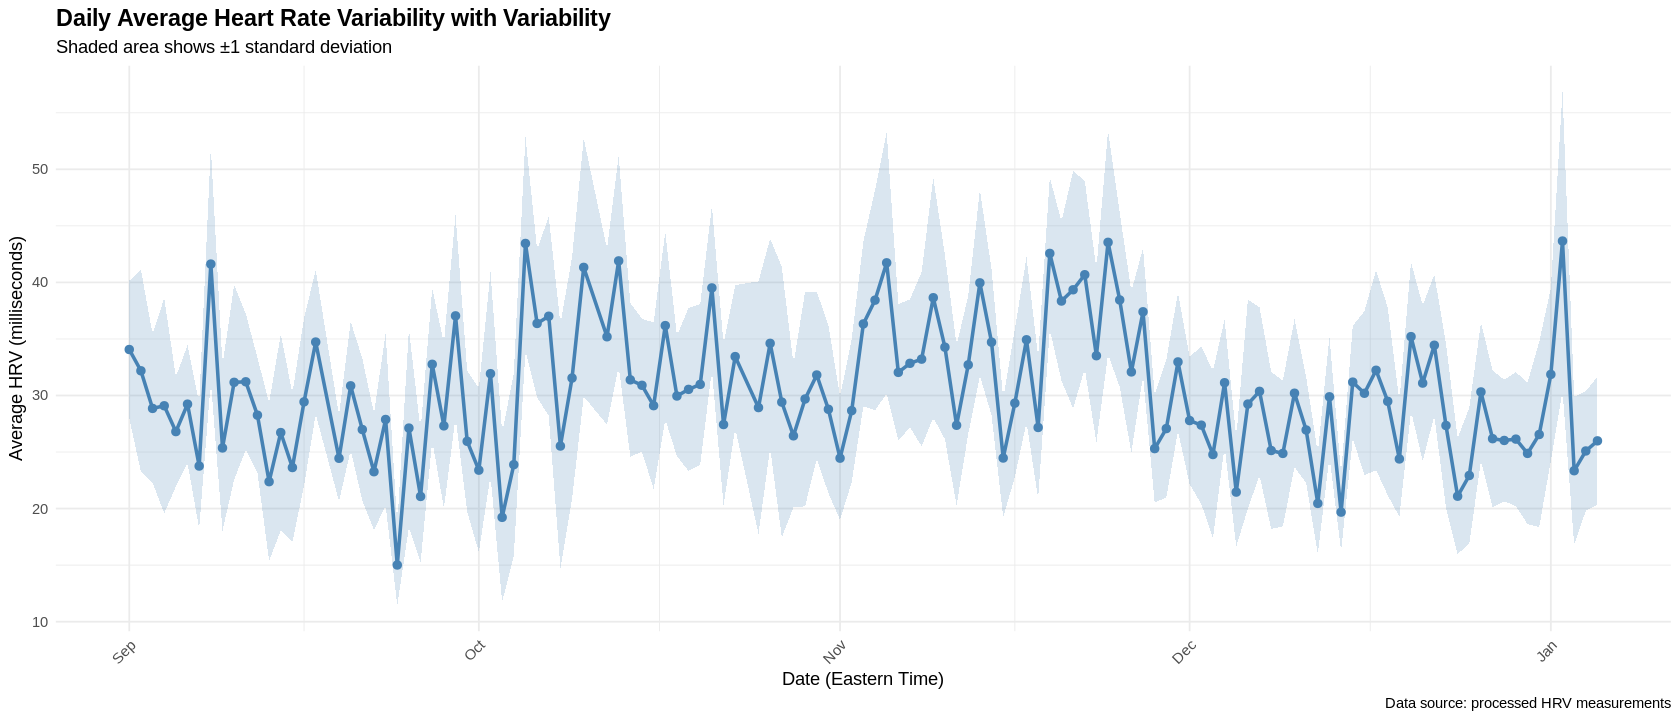

In [25]:
# ctrl + U   -> exposes the html code behind a website html
#$$
# THIS IS A NEW PLOT
# Set plot dimensions to be wider
options(repr.plot.width = 14, repr.plot.height = 6)
# Create daily HRV summary statistics from daty dataframe
daily_hrv_summary <- daty %>%
  mutate(calendarDate = as.Date(calendarDate)) %>%  # Ensure date is in Date format
  group_by(calendarDate) %>%
  summarise(
    mean_hrv = mean(hrvValue, na.rm = TRUE),        # Calculate average HRV per day
    median_hrv = median(hrvValue, na.rm = TRUE),    # Calculate median HRV per day
    min_hrv = min(hrvValue, na.rm = TRUE),          # Calculate minimum HRV per day
    max_hrv = max(hrvValue, na.rm = TRUE),          # Calculate maximum HRV per day
    sd_hrv = sd(hrvValue, na.rm = TRUE),            # Calculate standard deviation per day
    n = n(),                                         # Count number of HRV readings per day
    .groups = 'drop'
  )

# Create daily HRV summary visualization
daily_hrv_plot <- daily_hrv_summary %>%
  ggplot(aes(x = calendarDate, y = mean_hrv)) +    # Map date to x-axis, mean HRV to y-axis
  geom_line(color = "steelblue", size = 1) +       # Connect daily averages with line
  geom_point(color = "steelblue", size = 2) +      # Add points at each daily average
  geom_ribbon(
    aes(ymin = mean_hrv - sd_hrv, ymax = mean_hrv + sd_hrv),  # Create band showing ±1 SD
    alpha = 0.2,                                    # Make ribbon semi-transparent
    fill = "steelblue"                              # Use same color as line
  ) +
  labs(
    title = "Daily Average Heart Rate Variability with Variability",  # Main plot title
    subtitle = "Shaded area shows ±1 standard deviation",             # Explain the shaded region
    x = "Date (Eastern Time)",                                        # X-axis label
    y = "Average HRV (milliseconds)",                                 # Y-axis label
    caption = "Data source: processed HRV measurements"               # Data source attribution
  ) +
  theme_minimal() +                                 # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14), # Bold title with larger font
    plot.subtitle = element_text(size = 11)              # Subtitle with standard font
  )

# Display the daily HRV plot
print(daily_hrv_plot)

In [26]:
# Create summary statistics for heart rate data
data_summary <- data %>%
  mutate(date_et = date(time)) %>%  # Extract date from time column in Eastern Time
  group_by(date_et) %>%  # Group measurements by date in Eastern Time
  summarise(
    mean_hr = mean(heartrate, na.rm = TRUE),      # Calculate average heart rate per day
    median_hr = median(heartrate, na.rm = TRUE),  # Calculate median heart rate per day
    min_hr = min(heartrate, na.rm = TRUE),        # Calculate minimum heart rate per day
    max_hr = max(heartrate, na.rm = TRUE),        # Calculate maximum heart rate per day
    sd_hr = sd(heartrate, na.rm = TRUE),          # Calculate standard deviation per day
    n = n(),                                       # Count number of measurements per day
    .groups = 'drop'  # Drop grouping after summarization
  )

# Track data_summary dataframe with description
fx(data_summary, "data_summary contains daily heart rate statistics aggregated from data")

In [27]:
#print(data_summary)

In [28]:
#print(tail(data_summary))

Warning message:
“Removed 1 row containing missing values or values outside the scale range (`geom_line()`).”
Warning message:
“Removed 4 rows containing missing values or values outside the scale range (`geom_point()`).”


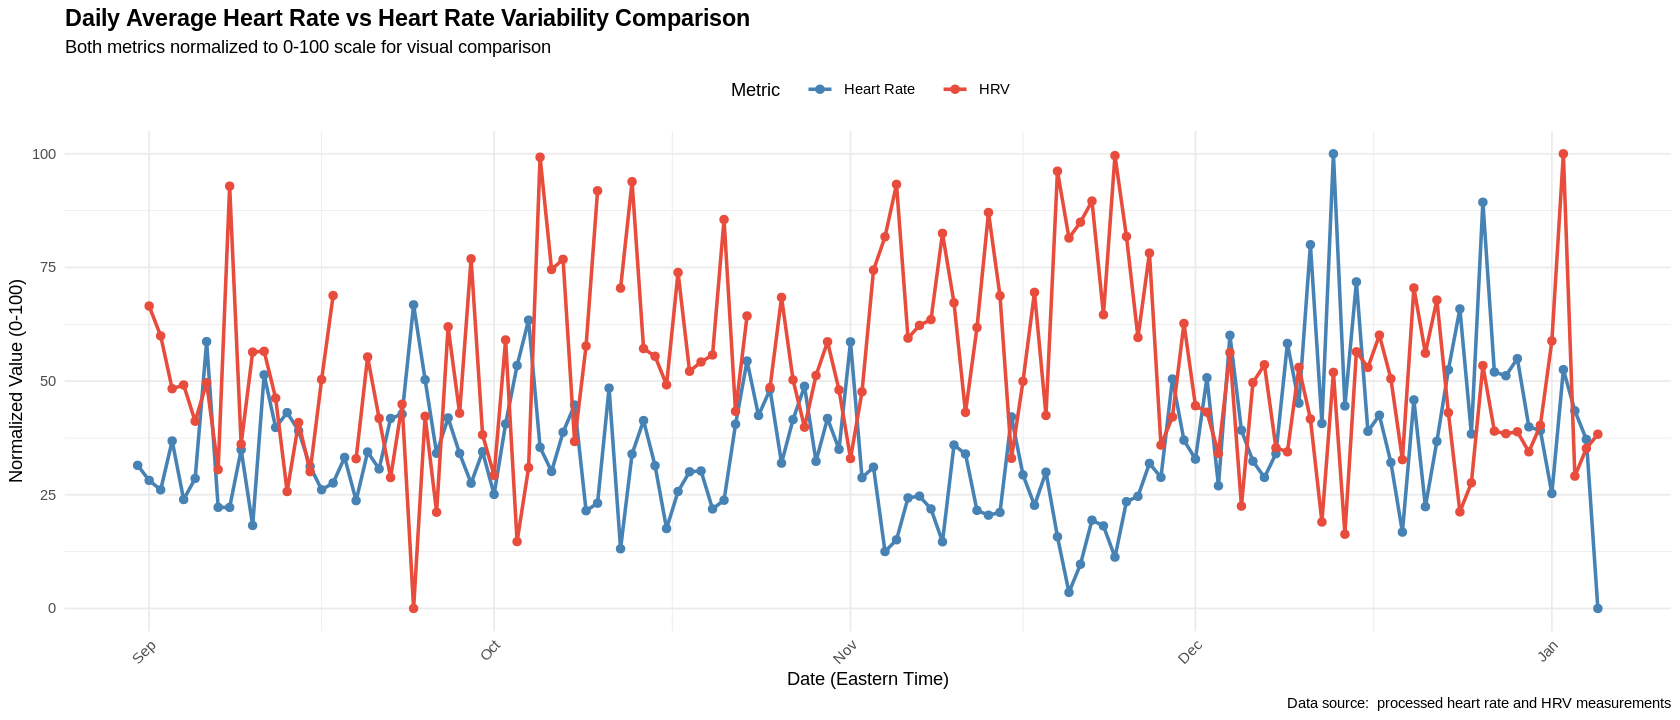

In [29]:
#$$
# Set plot dimensions to be wider
options(repr.plot.width = 14, repr.plot.height = 6)
# Create combined daily summary dataframe with both HR and HRV metrics
combined_summary <- data_summary %>%
  rename(date = date_et) %>%
  left_join(daily_hrv_summary, by = c("date" = "calendarDate"))

# Normalize both metrics to 0-100 scale for visual comparison on same plot
combined_summary <- combined_summary %>%
  mutate(
    mean_hr_normalized = (mean_hr - min(mean_hr, na.rm = TRUE)) /
      (max(mean_hr, na.rm = TRUE) - min(mean_hr, na.rm = TRUE)) * 100,
    mean_hrv_normalized = (mean_hrv - min(mean_hrv, na.rm = TRUE)) /
      (max(mean_hrv, na.rm = TRUE) - min(mean_hrv, na.rm = TRUE)) * 100
  )

# Create overlayed comparison plot with dual metrics
combined_plot <- combined_summary %>%
  ggplot(aes(x = date)) +
  # Heart Rate line in blue
  geom_line(aes(y = mean_hr_normalized, color = "Heart Rate"), size = 1) +
  geom_point(aes(y = mean_hr_normalized, color = "Heart Rate"), size = 2) +
  # HRV line in red
  geom_line(aes(y = mean_hrv_normalized, color = "HRV"), size = 1) +
  geom_point(aes(y = mean_hrv_normalized, color = "HRV"), size = 2) +
  scale_color_manual(values = c("Heart Rate" = "steelblue", "HRV" = "#E74C3C")) +
  labs(
    title = "Daily Average Heart Rate vs Heart Rate Variability Comparison",
    subtitle = "Both metrics normalized to 0-100 scale for visual comparison",
    x = "Date (Eastern Time)",
    y = "Normalized Value (0-100)",
    color = "Metric",
    caption = "Data source:  processed heart rate and HRV measurements"
  ) +
  theme_minimal() +
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),
    plot.title = element_text(face = "bold", size = 14),
    plot.subtitle = element_text(size = 11),
    legend.position = "top"
  )

# Display the combined plot
print(combined_plot)

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Failed to fit group -1.
Caused by error in `predLoess()`:
! workspace required (11808565553) is too large probably because of setting 'se = TRUE'.”


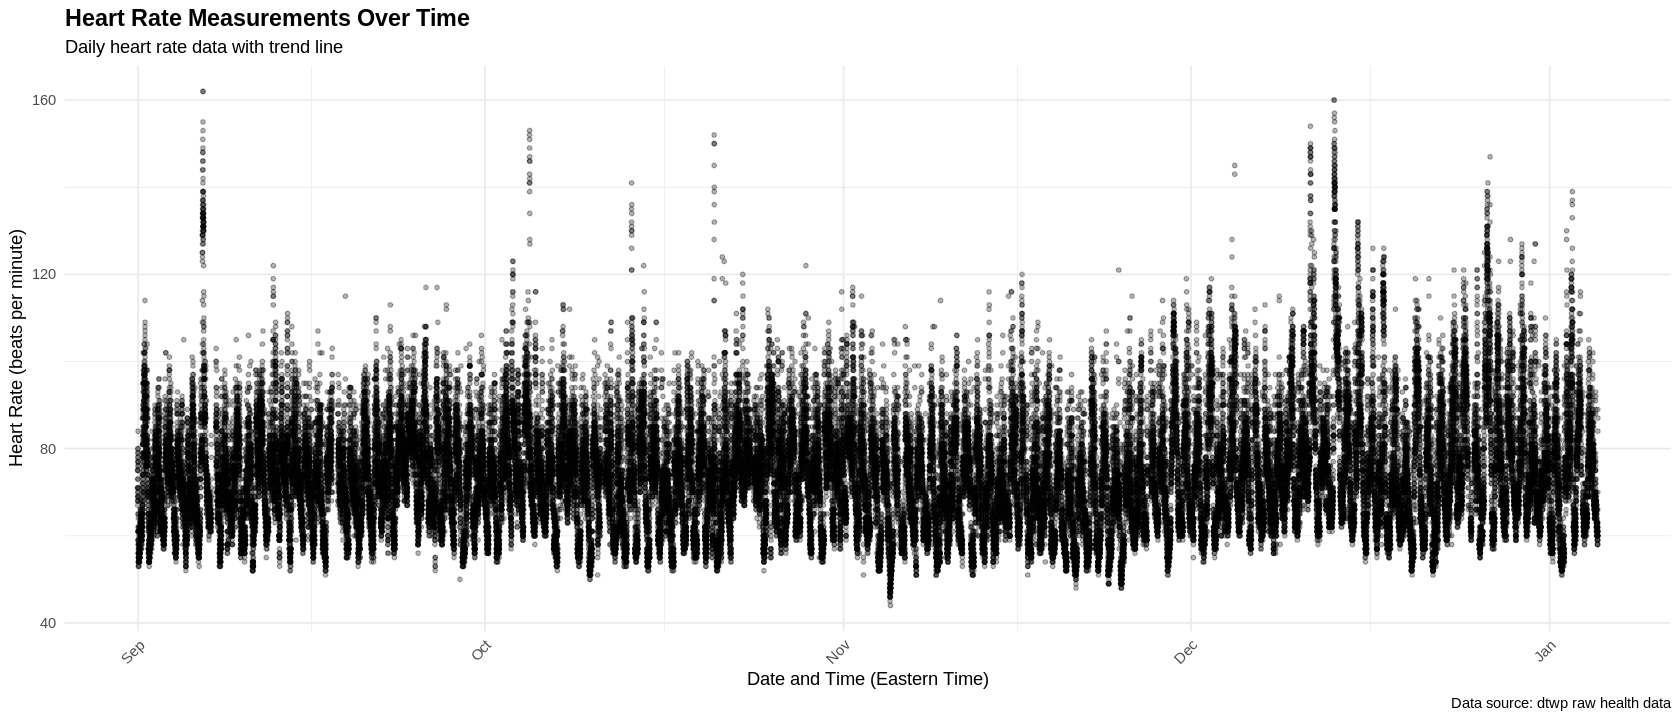

In [30]:


#$$
# Display first few rows of heart rate summary statistics
#show_tb(data_summary, 10)

#$$
# Create visualization of heart rate trends over time
hr_plot <- data %>%
  ggplot(aes(x = time, y = heartrate)) +  # Map time to x-axis, heart rate to y-axis
  geom_point(alpha = 0.3, size = 1) +         # Add points with transparency to show density
  geom_smooth(method = "loess", se = TRUE) +  # Add LOESS smoothing line with confidence interval
  labs(
    title = "Heart Rate Measurements Over Time",           # Main plot title
    subtitle = "Daily heart rate data with trend line",    # Descriptive subtitle
    x = "Date and Time (Eastern Time)",                    # X-axis label
    y = "Heart Rate (beats per minute)",                   # Y-axis label
    caption = "Data source: dtwp raw health data"          # Data source attribution
  ) +
  theme_minimal() +                           # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14),  # Bold title with larger font
    plot.subtitle = element_text(size = 11)               # Subtitle with standard font
  )

# Display the heart rate plot
print(hr_plot)

In [31]:
tail(data_summary)
tail(daily_hrv_summary)

date_et,mean_hr,median_hr,min_hr,max_hr,sd_hr,n
<date>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<int>
2025-12-31,74.70556,73,58,110,9.923881,720
2026-01-01,70.90139,68,53,105,12.435983,720
2026-01-02,78.38472,77,51,139,18.204618,720
2026-01-03,75.90046,76,56,116,12.831016,648
2026-01-04,74.16667,74,58,105,9.537132,720
2026-01-05,63.95200,63,58,89,4.669489,125


calendarDate,mean_hrv,median_hrv,min_hrv,max_hrv,sd_hrv,n
<date>,<dbl>,<dbl>,<int>,<int>,<dbl>,<int>
2025-12-31,26.55085,24.5,13,49,8.177097,118
2026-01-01,31.86538,33.0,19,45,7.628710,52
2026-01-02,43.65854,44.0,21,79,13.226628,82
2026-01-03,23.34783,22.0,15,39,6.523320,69
2026-01-04,25.09474,25.0,16,40,5.285616,95
2026-01-05,25.98980,26.0,12,36,5.672315,98


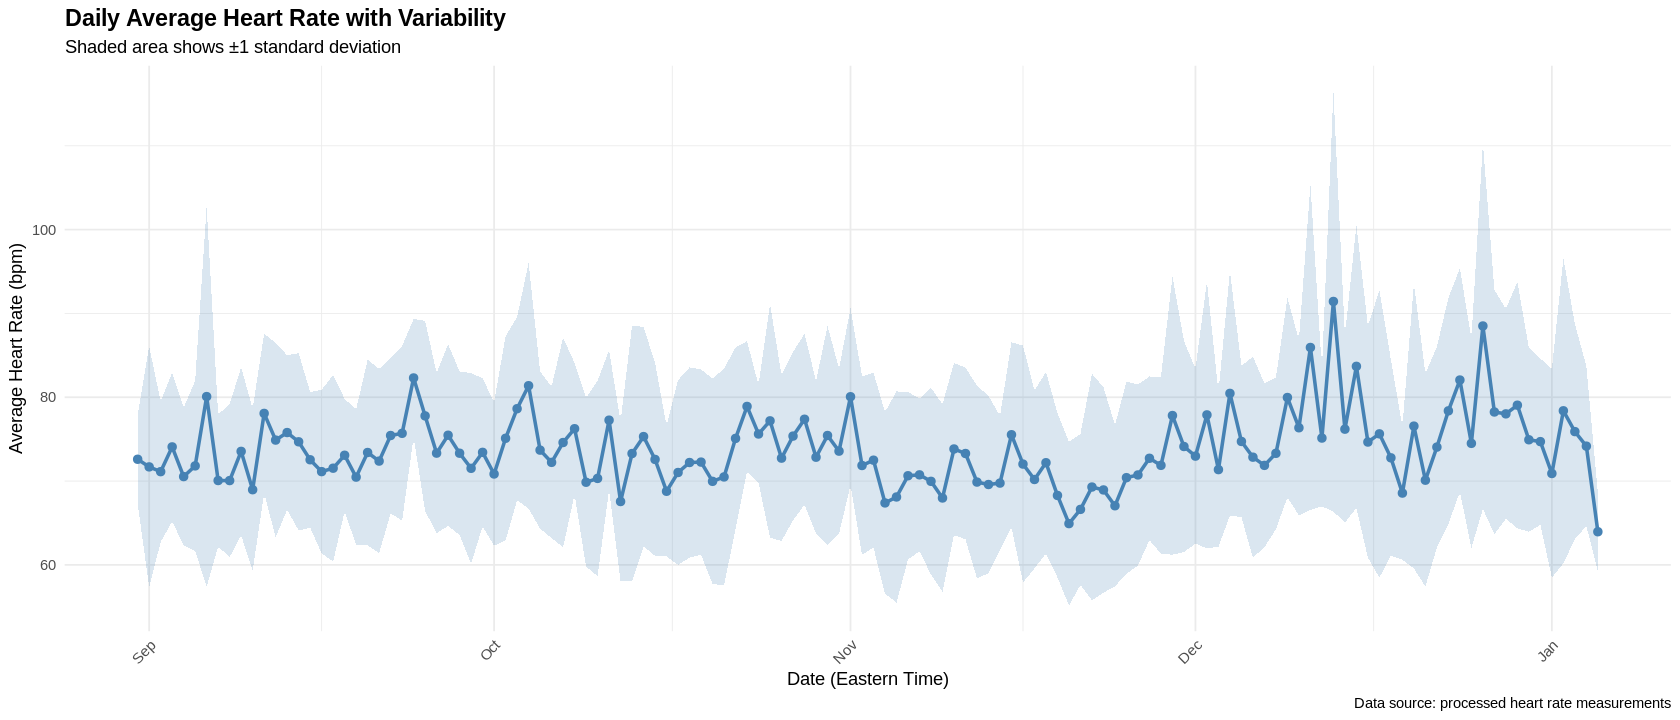

In [32]:
#$$
# Create daily heart rate summary visualization
daily_hr_plot <- data_summary %>%
  ggplot(aes(x = date_et, y = mean_hr)) +           # Map date to x-axis, mean heart rate to y-axis
  geom_line(color = "steelblue", size = 1) +        # Connect daily averages with line
  geom_point(color = "steelblue", size = 2) +       # Add points at each daily average
  geom_ribbon(
    aes(ymin = mean_hr - sd_hr, ymax = mean_hr + sd_hr),  # Create band showing ±1 SD
    alpha = 0.2,                                     # Make ribbon semi-transparent
    fill = "steelblue"                               # Use same color as line
  ) +
  labs(
    title = "Daily Average Heart Rate with Variability",  # Main plot title
    subtitle = "Shaded area shows ±1 standard deviation", # Explain the shaded region
    x = "Date (Eastern Time)",                            # X-axis label
    y = "Average Heart Rate (bpm)",                       # Y-axis label
    caption = "Data source: processed heart rate measurements"  # Data source attribution
  ) +
  theme_minimal() +                                  # Use minimal clean theme
  theme(
    axis.text.x = element_text(angle = 45, hjust = 1),  # Rotate x-axis labels for readability
    plot.title = element_text(face = "bold", size = 14), # Bold title with larger font
    plot.subtitle = element_text(size = 11)              # Subtitle with standard font
  )

# Display the daily heart rate plot
print(daily_hr_plot)

In [33]:
#$$
# Export processed heart rate data to CSV file
write.csv(data,
           file = "heart_rate_processed.csv",  # Output filename
           row.names = FALSE)                   # Exclude row numbers from output

# Export daily summary statistics to CSV file
write.csv(data_summary,
          file = "heart_rate_daily_summary.csv",  # Output filename
          row.names = FALSE)                       # Exclude row numbers from output

# Print confirmation messages
message("Exported processed heart rate data to:  heart_rate_processed.csv")
message("Exported daily summary statistics to: heart_rate_daily_summary.csv")

#$$
# Display final summary of all tracked dataframes
print(all_names)

Exported processed heart rate data to:  heart_rate_processed.csv

Exported daily summary statistics to: heart_rate_daily_summary.csv



      dataframe
1          dtwp
2            de
3         dtwp1
4         dtwp2
5          data
6           de1
7            dg
8           dg1
9      dg2_proc
10     dg2_flat
11     dg3_flat
12         daty
13  daily_lines
14 data_summary
                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                columns
1                                                                                                                                                               

In [34]:
#$$
# Display comments for each tracked dataframe
cat("=== DATAFRAME TRACKING SUMMARY ===\n\n")

for (i in 1:nrow(all_names)) {
  # Print dataframe name as header
  cat("Dataframe: ", all_names$dataframe[i], "\n")

  # Print associated columns
  cat("Columns:  ", all_names$columns[i], "\n")

  # Print associated comments if they exist
  if (all_names$comment[i] != "") {
    cat("Comments:\n", all_names$comment[i], "\n")
  } else {
    cat("Comments:  None\n")
  }

  # Print separator line between dataframes
  cat("\n---\n\n")
}

#$$
# Create a final report document summarizing the analysis
report <- paste(
  "HEART RATE DATA ANALYSIS REPORT",
  "================================\n",
  "Generated:  ", format(Sys.time(), "%Y-%m-%d %H:%M:%S"), "\n\n",

  "DATA PROCESSING SUMMARY:",
  "------------------------",
  "1.  Extracted heart rate and calendar date from raw df",
  "2. Parsed JSON heart rate values from string format",
  "3. Unnested heart rate data into individual measurements",
  "4. Converted millisecond timestamps to readable datetime",
  "5. Converted UTC times to Eastern Time Zone",
  "6. Extracted date component for daily aggregation\n",

  "DESCRIPTIVE STATISTICS:",
  "------------------------",
  paste("Total measurements:  ", nrow(data)),
  paste("Date range: ", min(data$date_et), " to ", max(data$date_et)),
  paste("Overall mean heart rate: ", round(mean(data$heartrate, na.rm = TRUE), 2), " bpm"),
  paste("Overall median heart rate: ", round(median(data$heartrate, na.rm = TRUE), 2), " bpm"),
  paste("Overall min heart rate: ", min(data$heartrate, na.rm = TRUE), " bpm"),
  paste("Overall max heart rate: ", max(data$heartrate, na.rm = TRUE), " bpm\n"),

  "FILES GENERATED:",
  "------------------------",
  "- heart_rate_processed.csv (detailed measurements)",
  "- heart_rate_daily_summary.csv (daily statistics)",
  "- hr_plot (time series visualization)",
  "- daily_hr_plot (daily average trends)\n",

  sep = "\n"
)

# Print the report
cat(report)

# Optionally save report to text file
writeLines(report, "heart_rate_analysis_report.txt")
message("\nReport saved to:  heart_rate_analysis_report.txt")

#$$
# Session cleanup and final notes
cat("\n=== ANALYSIS COMPLETE ===\n\n")

cat("Key Findings:\n")
cat("- Heart rate data successfully processed and organized\n")
cat("- Data converted from UTC to Eastern Time Zone\n")
cat("- Daily summaries calculated with statistical measures\n")
cat("- Visualizations created showing trends and variability\n\n")

cat("All dataframes tracked in 'all_names':\n")
print(all_names$dataframe)

cat("\nTo review any dataframe's description, use:\n")
cat("  df_comms(dataframe_name)\n\n")

cat("To see all current dataframes, use:\n")
cat("  curr_df()\n\n")

cat("To reset tracking, use:\n")
cat("  reset_fx()\n\n")

cat("Analysis workflow complete. All outputs saved.\n")

=== DATAFRAME TRACKING SUMMARY ===

Dataframe:  dtwp 
Columns:   calendarDate, heartRateValues 
Comments:
 takes these 2 columns from df - CLEANED 

---

Dataframe:  de 
Columns:   summaryDate, userProfilePK, calendarDate, startTimestampGMT, endTimestampGMT, startTimestampLocal, endTimestampLocal, maxHeartRate, minHeartRate, restingHeartRate, lastSevenDaysAvgRestingHeartRate, userProfilePk, hrvSummary, hrvReadings, sleepStartTimestampGMT, sleepEndTimestampGMT, sleepStartTimestampLocal, sleepEndTimestampLocal, tomorrowSleepStartTimestampGMT, tomorrowSleepEndTimestampGMT, tomorrowSleepStartTimestampLocal, tomorrowSleepEndTimestampLocal, lowestRespirationValue, highestRespirationValue, avgWakingRespirationValue, avgSleepRespirationValue, avgTomorrowSleepRespirationValue 
Comments:
 de takes everything from df except heartRateValues and heartRateValueDescriptors 

---

Dataframe:  dtwp1 
Columns:   calendarDate, heartRateValues 
Comments:
 dtwp1 parses JSON - WITH ERROR HANDLING 

---

Dat

Warning message in min(data$date_et):
“no non-missing arguments to min; returning Inf”
Warning message in max(data$date_et):
“no non-missing arguments to max; returning -Inf”


HEART RATE DATA ANALYSIS REPORT

Generated:  
2026-01-05 12:41:57



DATA PROCESSING SUMMARY:
------------------------
1.  Extracted heart rate and calendar date from raw df
2. Parsed JSON heart rate values from string format
3. Unnested heart rate data into individual measurements
4. Converted millisecond timestamps to readable datetime
5. Converted UTC times to Eastern Time Zone
6. Extracted date component for daily aggregation

DESCRIPTIVE STATISTICS:
------------------------
Total measurements:   88723
Date range:  Inf  to  -Inf
Overall mean heart rate:  73.88  bpm
Overall median heart rate:  73  bpm
Overall min heart rate:  44  bpm
Overall max heart rate:  162  bpm

FILES GENERATED:
------------------------
- heart_rate_processed.csv (detailed measurements)
- heart_rate_daily_summary.csv (daily statistics)
- hr_plot (time series visualization)
- daily_hr_plot (daily average trends)



Report saved to:  heart_rate_analysis_report.txt




=== ANALYSIS COMPLETE ===

Key Findings:
- Heart rate data successfully processed and organized
- Data converted from UTC to Eastern Time Zone
- Daily summaries calculated with statistical measures
- Visualizations created showing trends and variability

All dataframes tracked in 'all_names':
 [1] "dtwp"         "de"           "dtwp1"        "dtwp2"        "data"         "de1"          "dg"           "dg1"          "dg2_proc"     "dg2_flat"     "dg3_flat"     "daty"         "daily_lines"  "data_summary"

To review any dataframe's description, use:
  df_comms(dataframe_name)

To see all current dataframes, use:
  curr_df()

To reset tracking, use:
  reset_fx()

Analysis workflow complete. All outputs saved.


In [82]:
# Simple keep-alive loop - print every 2 seconds with counter
for (i in 1:1000) {
  cat("\r", "cat", i)
  flush.console()
  Sys.sleep(10)
}

 cat 241

Beginning Monday, January 5, 2026

In [37]:
# CHUNK 1: Sleep Duration Analysis - Extract earliest and latest times

# Extract earliest and latest clock times for each day
# Groups data by calendar date and finds min/max reading times
time_summary <- daty %>%
  group_by(calendarDate) %>%
  summarise(
    # Format earliest time as HH:MM:SS
    earliest = format(min(readingTimeLocal, na.rm = TRUE), "%H:%M:%S"),
    # Format latest time as HH:MM:SS
    latest = format(max(readingTimeLocal, na.rm = TRUE), "%H:%M:%S"),
    # Create time range string (e.g., "22:30:00 - 07:15:00")
    time_range = paste(earliest, "-", latest),
    .groups = "drop"
  ) %>%
  # Keep only calendar date and time range columns
  select(calendarDate, time_range)

# Display summary of time_summary dataframe
fx(time_summary, "time_summary extracts earliest/latest times for each day")

In [40]:
# CHUNK 2: Sleep Duration Analysis - Calculate sleep duration from time range

# Start with time_summary from Chunk 1
# Extract individual start and end times from the combined time_range string
time_summary <- time_summary %>%
  mutate(
    # Extract start time using regex pattern (HH:MM:SS at beginning)
    start_time = str_extract(time_range, "^\\d{2}:\\d{2}:\\d{2}"),
    # Extract end time using regex pattern (HH:MM:SS at end)
    end_time = str_extract(time_range, "\\d{2}:\\d{2}:\\d{2}$"),

    # Convert start time string to seconds since midnight
    start_sec = period_to_seconds(hms(start_time)),
    # Convert end time string to seconds since midnight
    end_sec = period_to_seconds(hms(end_time)),

    # Calculate sleep duration in decimal hours
    # If end_sec >= start_sec:  simple subtraction (same day sleep)
    # Otherwise: account for overnight sleep (crosses midnight)
    sleep_time = if_else(
      end_sec >= start_sec,
      (end_sec - start_sec) / 3600,
      ((86400 - start_sec) + end_sec) / 3600
    )
  ) %>%
  # Keep only the essential columns for downstream analysis
  select(calendarDate, time_range, sleep_time)
  kable(time_summary)



|calendarDate |time_range          | sleep_time|
|:------------|:-------------------|----------:|
|2025-09-01   |00:47:44 - 08:17:44 |   7.500000|
|2025-09-02   |21:42:45 - 03:27:45 |   5.750000|
|2025-09-03   |22:12:44 - 07:27:44 |   9.250000|
|2025-09-04   |20:57:44 - 07:47:44 |  10.833333|
|2025-09-05   |23:07:44 - 05:57:44 |   6.833333|
|2025-09-06   |02:47:44 - 08:42:44 |   5.916667|
|2025-09-07   |22:27:44 - 07:27:44 |   9.000000|
|2025-09-08   |00:12:44 - 04:57:44 |   4.750000|
|2025-09-09   |21:12:44 - 04:02:44 |   6.833333|
|2025-09-10   |20:57:44 - 06:29:09 |   9.523611|
|2025-09-11   |21:29:09 - 03:39:09 |   6.166667|
|2025-09-12   |22:24:09 - 06:34:09 |   8.166667|
|2025-09-13   |23:29:48 - 05:59:48 |   6.500000|
|2025-09-14   |22:39:48 - 04:54:48 |   6.250000|
|2025-09-15   |23:04:48 - 07:19:48 |   8.250000|
|2025-09-16   |23:44:48 - 06:19:48 |   6.583333|
|2025-09-17   |22:53:37 - 06:08:37 |   7.250000|
|2025-09-19   |23:13:37 - 05:18:37 |   6.083333|
|2025-09-20   |00:

In [42]:
# CHUNK 3: Sleep Duration Analysis - Calculate average sleep by day of week

# Start with time_summary from Chunk 2
# Calculate average sleep duration grouped by day of the week
sleep_by_night <- time_summary %>%
  mutate(
    # Convert calendarDate from character to Date class (if not already)
    calendarDate = as.Date(calendarDate),
    # Shift date back by one day to reflect the night sleep actually began
    # (e.g., sleep on Sunday night = Monday morning, so shift to Sunday)
    sleep_night = calendarDate - days(1),
    # Extract the full weekday name (Monday, Tuesday, etc.)
    day_of_week = weekdays(sleep_night)
  ) %>%
  # Group by day of week to aggregate across all weeks
  group_by(day_of_week) %>%
  summarise(
    # Calculate mean sleep time for each day, rounded to 2 decimal places
    average_sleep = round(mean(sleep_time, na.rm = TRUE), 2),
    .groups = "drop"
  )

# Display sleep_by_night as a formatted table
kable(sleep_by_night)



|day_of_week | average_sleep|
|:-----------|-------------:|
|Friday      |          7.09|
|Monday      |          6.71|
|Saturday    |          7.16|
|Sunday      |          6.40|
|Thursday    |          6.82|
|Tuesday     |          7.09|
|Wednesday   |          7.18|

In [44]:
# CHUNK 4: Sleep Duration Analysis - Create interactive plot with sleep duration over time

# Start with time_summary from Chunk 2
# Calculate the overall average sleep duration across all days
avg_sleep <- mean(time_summary$sleep_time, na.rm = TRUE)

# Format table text for annotation display on the plot
# This creates a multi-line string showing average sleep by day of week
table_text <- paste0(
  "Average Sleep by Night:\n",
  paste(sleep_by_night$day_of_week, ": ", sleep_by_night$average_sleep, " hrs", collapse = "\n")
)

# Create interactive scatter plot with lines and markers
# Shows sleep duration for each calendar date
p1 <- plot_ly(time_summary, x = ~calendarDate, y = ~sleep_time, type = 'scatter', mode = 'lines+markers',
        name = 'Sleep Time') %>%
  layout(
    # Set plot title
    title = 'Sleep Duration Over Time',
    # Configure x-axis (dates)
    xaxis = list(title = 'Date', tickangle = -90),
    # Configure y-axis (sleep hours)
    yaxis = list(title = 'Sleep Time (hours)'),
    # Add horizontal reference line for average sleep
    shapes = list(
      list(
        type = "line",
        # Line spans from earliest to latest date
        x0 = min(time_summary$calendarDate),
        x1 = max(time_summary$calendarDate),
        # Both y values equal average sleep (creates horizontal line)
        y0 = avg_sleep,
        y1 = avg_sleep,
        # Style:  red dashed line
        line = list(color = "red", dash = "dash")
      )
    ),
    # Add annotations to the plot
    annotations = list(
      # Annotation 1: Label for average sleep line
      list(
        # Position at max date and avg_sleep value
        x = max(time_summary$calendarDate),
        y = avg_sleep,
        # Display average sleep value
        text = paste("Average Sleep Time:", round(avg_sleep, 2), "hrs"),
        # Use data coordinates for positioning
        xref = "x",
        yref = "y",
        showarrow = FALSE,
        # Red font to match the line
        font = list(color = "red")
      ),
      # Annotation 2: Table showing average sleep by day of week
      list(
        # Position in upper right corner (paper coordinates:  0-1 scale)
        x = 0.98,
        y = 0.98,
        # Display the formatted table text
        text = table_text,
        # Use paper coordinates (plot area normalized to 0-1)
        xref = "paper",
        yref = "paper",
        showarrow = FALSE,
        align = "left",
        # Style the annotation box
        font = list(size = 12),
        bgcolor = "rgba(255,255,255,0.8)",
        bordercolor = "black",
        borderwidth = 1
      )
    )
  )

print(p1)
htmlwidgets::saveWidget(p1, "plot2HRV.html")

In [46]:
# CHUNK 5: Statistical Analysis - HRV Kruskal-Wallis Test
# Calculate summary statistics for HRV (Heart Rate Variability) by calendar date
# Produces quartiles, median, min, max, and IQR for each day
stats <- daty %>%
  group_by(calendarDate) %>%
  summarise(
    # Minimum HRV value for the day
    Min = min(hrvValue, na.rm = TRUE),
    # First quartile (25th percentile) - lower quarter of data
    Q1 = quantile(hrvValue, 0.25, na.rm = TRUE),
    # Median (50th percentile) - middle value
    Median = median(hrvValue, na.rm = TRUE),
    # Third quartile (75th percentile) - upper quarter of data
    Q3 = quantile(hrvValue, 0.75, na.rm = TRUE),
    # Maximum HRV value for the day
    Max = max(hrvValue, na.rm = TRUE),
    # Interquartile range (Q3 - Q1) - spread of middle 50%
    IQR = IQR(hrvValue, na.rm = TRUE),
    .groups = "drop"
  )
# Display stats summary
fx(stats, "stats contains quartiles and IQR for HRV by date (for Kruskal-Wallis test)")

# Kruskal-Wallis test:  non-parametric test to determine if HRV distributions differ significantly between days
# Null hypothesis: HRV distributions are the same across all calendar dates
# Alternative:  At least one day has a different HRV distribution
kruskal <- kruskal.test(hrvValue ~ calendarDate, data = daty)

# Identify the day with the highest median HRV (potential anomaly or unusual day)
anomaly_day <- stats %>%
  filter(Median == max(Median)) %>%
  pull(calendarDate)

# Add color flag column to daty dataframe for visualization purposes
# Colors the anomalous day differently from normal days
daty <- daty %>%
  mutate(colorFlag = ifelse(calendarDate == anomaly_day, "Anomaly", "Normal"))

# Create interactive box plot showing HRV distribution for each calendar date
p2 <- plot_ly(
  data = daty,
  x = ~calendarDate,
  y = ~hrvValue,
  type = "box",
  # Color by the colorFlag (Anomaly vs Normal)
  color = ~colorFlag,
  # Define colors:   blue for normal, red for anomaly
  colors = c("Normal" = "#3498DB", "Anomaly" = "#E74C3C"),
  # Show all individual data points
  boxpoints = "all",
  # Add jitter to spread out overlapping points
  jitter = 0.3,
  # Position points relative to box
  pointpos = 0
) %>%
  layout(
    title = "HRV Box Plot by Day with Anomaly Highlighted",
    xaxis = list(title = "Date"),
    yaxis = list(title = "HRV (ms)")
  )

# Display the box plot
print(p2)
htmlwidgets::saveWidget(p2, "plot3HRV.html")
# Print Kruskal-Wallis test p-value
cat("\nKruskal-Wallis p-value:", kruskal$p.value, "\n")
# Print which day was identified as anomalous
cat("Anomalous day identified:", anomaly_day, "\n")




Kruskal-Wallis p-value: 0 
Anomalous day identified: 2025-11-24 2026-01-02 


In [51]:
# CHUNK 6: Statistical Analysis - HRV Dunn's Post-Hoc Test

# Dunn's test:   post-hoc pairwise comparison test
# Identifies which specific pairs of days have significantly different HRV distributions
# Uses Benjamini-Hochberg method to control for multiple comparisons
dunn <- dunnTest(hrvValue ~ calendarDate, data = daty, method = "bh")
# Extract the results dataframe containing all pairwise comparisons
dunn_results <- dunn$res
# Display Dunn's test results
fx(dunn_results, "dunn_results contains pairwise comparisons of HRV between each day")

# Extract days with statistically significant differences
# Filters comparisons where adjusted p-value is less than 0.05 (p < 0.05)
# Splits the comparison strings (e.g., "2025-01-01 - 2025-01-02") to get individual dates
sig_days <- unique(unlist(strsplit(
  dunn_results$Comparison[dunn_results$P.adj < 0.05], " - "
)))

# Add color flag column to daty dataframe for visualization
# Colors days with significant differences differently from normal days
daty <- daty %>%
  mutate(colorFlag = ifelse(calendarDate %in% sig_days, "Significant", "Normal"))

# Create updated interactive box plot highlighting significantly different days
p3 <- plot_ly(
  data = daty,
  x = ~calendarDate,
  y = ~hrvValue,
  type = "box",
  # Color by the updated colorFlag (Significant vs Normal)
  color = ~colorFlag,
  # Define colors:  dark blue for normal, red for significant
  colors = c("Normal" = "#1f78b4", "Significant" = "#e31a1c"),
  # Show all individual data points on the plot
  boxpoints = "all",
  # Add jitter to spread out overlapping points for clarity
  jitter = 0.25,
  # Position points relative to box center
  pointpos = 0,
  # Style the individual points
  marker = list(size = 2.5, opacity = 0.6)
) %>%
  layout(
    title = "HRV Box Plot by Day with Statistically Different Days Highlighted",
    xaxis = list(title = "Date"),
    yaxis = list(title = "HRV (ms)")
  )

# Display the updated box plot
print(p3)
# Print Kruskal-Wallis test p-value (from Chunk 5)
cat("\nKruskal-Wallis p-value:", kruskal$p.value, "\n")
# Print header for significantly different days
cat("Statistically different days identified:\n")
# Print the list of days with significant differences
print(sig_days)
htmlwidgets::saveWidget(p3, "plot4HRV.html")

Warning message:
“calendarDate was coerced to a factor.”



Kruskal-Wallis p-value: 0 
Statistically different days identified:
  [1] "2025-09-01" "2025-09-03" "2025-09-04" "2025-09-02" "2025-09-05" "2025-09-06" "2025-09-07" "2025-09-08" "2025-09-09" "2025-09-10" "2025-09-11" "2025-09-12" "2025-09-13" "2025-09-14" "2025-09-15" "2025-09-16" "2025-09-17" "2025-09-19" "2025-09-20" "2025-09-21" "2025-09-22" "2025-09-23"
 [23] "2025-09-24" "2025-09-25" "2025-09-26" "2025-09-27" "2025-09-28" "2025-09-29" "2025-09-30" "2025-10-01" "2025-10-02" "2025-10-03" "2025-10-04" "2025-10-05" "2025-10-06" "2025-10-07" "2025-10-08" "2025-10-09" "2025-10-10" "2025-10-12" "2025-10-13" "2025-10-14" "2025-10-15" "2025-10-16"
 [45] "2025-10-17" "2025-10-18" "2025-10-19" "2025-10-20" "2025-10-21" "2025-10-22" "2025-10-23" "2025-10-25" "2025-10-26" "2025-10-27" "2025-10-28" "2025-10-29" "2025-10-30" "2025-10-31" "2025-11-01" "2025-11-02" "2025-11-03" "2025-11-04" "2025-11-05" "2025-11-06" "2025-11-07" "2025-11-08"
 [67] "2025-11-09" "2025-11-10" "2025-11-11" "2025-11-1

In [57]:
# CHUNK 7.1: Time Series Analysis - Heart Rate Decomposition (Diagnostic)

# Convert data to a time-aware tibble with time index
data_ts <- as_tbl_time(data, index = time)
fx(data_ts, "data_ts is time-indexed tibble for time series analysis of heart rate (bpm)")

# Apply STL decomposition and anomaly detection
results <- data_ts %>%
  time_decompose(heartrate, method = "stl", frequency = "auto", trend = "auto") %>%
  anomalize(remainder, method = "iqr") %>%
  time_recompose()
fx(results, "results contains time series decomposition and anomaly flags")

# DIAGNOSTIC:   Examine structure of results
cat("\n=== RESULTS STRUCTURE ===\n")
cat("Class:", class(results), "\n")
cat("Dimensions:", nrow(results), "rows x", ncol(results), "columns\n")
cat("Column names:", names(results), "\n\n")

# DIAGNOSTIC:  Examine the 'time' column
cat("=== TIME COLUMN INFO ===\n")
cat("Class of 'time' column:", class(results$time), "\n")
cat("First 5 values of 'time':\n")
print(head(results$time, 5))

frequency = 720 minutes

trend = 9812 minutes




=== RESULTS STRUCTURE ===
Class: tbl_time tbl_df tbl data.frame 
Dimensions: 88723 rows x 10 columns
Column names: time observed season trend remainder remainder_l1 remainder_l2 anomaly recomposed_l1 recomposed_l2 

=== TIME COLUMN INFO ===
Class of 'time' column: POSIXct POSIXt 
First 5 values of 'time':
[1] "2025-08-31 23:00:00 EDT" "2025-08-31 23:02:00 EDT" "2025-08-31 23:04:00 EDT" "2025-08-31 23:06:00 EDT" "2025-08-31 23:08:00 EDT"


In [59]:
# CHUNK 7.2: Convert POSIXct time to Date and examine

# Create calendarDate from the POSIXct 'time' column
results <- results %>%
  mutate(calendarDate = as.Date(time))

# DIAGNOSTIC:  Check calendarDate column
cat("\n=== CALENDADATE COLUMN INFO ===\n")
cat("Class of 'calendarDate' column:", class(results$calendarDate), "\n")
cat("First 5 values of 'calendarDate':\n")
print(head(results$calendarDate, 5))

# DIAGNOSTIC: Check for any NAs
cat("\nNumber of NAs in calendarDate:", sum(is.na(results$calendarDate)), "\n")

# DIAGNOSTIC: Examine de1 dataframe
cat("\n=== DE1 DATAFRAME INFO ===\n")
cat("Class of 'de1$calendarDate':", class(de1$calendarDate), "\n")
cat("First 5 values of de1$calendarDate:\n")
print(head(de1$calendarDate, 5))
cat("\nNumber of NAs in de1$calendarDate:", sum(is.na(de1$calendarDate)), "\n")


=== CALENDADATE COLUMN INFO ===
Class of 'calendarDate' column: Date 
First 5 values of 'calendarDate':
[1] "2025-09-01" "2025-09-01" "2025-09-01" "2025-09-01" "2025-09-01"

Number of NAs in calendarDate: 0 

=== DE1 DATAFRAME INFO ===
Class of 'de1$calendarDate': character 
First 5 values of de1$calendarDate:
[1] "2025-08-20" "2025-08-21" "2025-08-22" "2025-08-23" "2025-08-24"

Number of NAs in de1$calendarDate: 0 


In [60]:
# CHUNK 7.3: Convert de1$calendarDate to Date and join

# Convert de1$calendarDate from character to Date class
# This ensures both sides of the join use the same data type
de1 <- de1 %>%
  mutate(calendarDate = as.Date(calendarDate))

# DIAGNOSTIC: Verify conversion
cat("\n=== CONVERTED DE1 DATAFRAME INFO ===\n")
cat("Class of 'de1$calendarDate' (after conversion):", class(de1$calendarDate), "\n")
cat("First 5 values of de1$calendarDate:\n")
print(head(de1$calendarDate, 5))

# Join the anomaly detection results with daily heart rate statistics from de1 dataframe
# Both calendarDate columns are now <Date> class, so join will work
tab <- results %>%
  left_join(de1, by = "calendarDate")

# DIAGNOSTIC: Check the joined result
cat("\n=== JOINED TABLE INFO ===\n")
cat("Dimensions:", nrow(tab), "rows x", ncol(tab), "columns\n")
cat("Column names:", names(tab), "\n")
cat("First 5 rows of tab:\n")
print(head(tab, 5))

# Display combined results
fx(tab, "tab combines anomalies from results with daily HR stats from de1")


=== CONVERTED DE1 DATAFRAME INFO ===
Class of 'de1$calendarDate' (after conversion): Date 
First 5 values of de1$calendarDate:
[1] "2025-08-20" "2025-08-21" "2025-08-22" "2025-08-23" "2025-08-24"

=== JOINED TABLE INFO ===
Dimensions: 88723 rows x 15 columns
Column names: time observed season trend remainder remainder_l1 remainder_l2 anomaly recomposed_l1 recomposed_l2 calendarDate maxHeartRate minHeartRate restingHeartRate lastSevenDaysAvgRestingHeartRate 
First 5 rows of tab:
# A time tibble: 5 × 15
# Index:         time
  time                observed season trend remainder remainder_l1 remainder_l2 anomaly recomposed_l1 recomposed_l2 calendarDate maxHeartRate minHeartRate restingHeartRate lastSevenDaysAvgRestingHeartRate
  <dttm>                 <dbl>  <dbl> <dbl>     <dbl>        <dbl>        <dbl> <chr>           <dbl>         <dbl> <date>       <chr>        <chr>        <chr>            <chr>                           
1 2025-08-31 23:00:00       75  0.385  70.5    4.15         

In [61]:
# CHUNK 7: Time Series Analysis - Heart Rate Decomposition and Anomaly Detection

# Convert data to a time-aware tibble with time index
# This prepares the data for time series analysis and decomposition
data_ts <- as_tbl_time(data, index = time)
# Display summary of time-indexed tibble
fx(data_ts, "data_ts is time-indexed tibble for time series analysis of heart rate (bpm)")

# Apply STL (Seasonal and Trend decomposition using Loess) to heart rate data
# STL decomposes the time series into three components:
#   - trend: long-term direction
#   - seasonal: repeating patterns
#   - remainder: anomalies and irregular variations
# Then apply anomaly detection using the IQR (Interquartile Range) method
# The IQR method flags points in the remainder as anomalies if they fall outside expected range
results <- data_ts %>%
  # Decompose heart rate using STL with automatic frequency and trend parameters
  time_decompose(heartrate, method = "stl", frequency = "auto", trend = "auto") %>%
  # Apply IQR-based anomaly detection to the remainder component
  anomalize(remainder, method = "iqr") %>%
  # Recompose the time series with anomaly flags
  time_recompose()
# Display results from decomposition and anomaly detection
fx(results, "results contains time series decomposition and anomaly flags for heartrate")

# Extract calendar date from the POSIXct 'time' column
# Convert timestamp to date (YYYY-MM-DD format) for grouping
results <- results %>%
  mutate(calendarDate = as.Date(time))

# Convert de1$calendarDate from character to Date class
# This ensures both sides of the join use the same data type
de1 <- de1 %>%
  mutate(calendarDate = as.Date(calendarDate))

# Join the anomaly detection results with daily heart rate statistics from de1 dataframe
# This combines individual time-point anomalies with daily summary statistics
tab <- results %>%
  left_join(de1, by = "calendarDate")
# Display combined results
fx(tab, "tab combines anomalies from results with daily HR stats from de1")

frequency = 720 minutes

trend = 9812 minutes



In [74]:
# CHUNK 8: Visualization - Interactive plot of anomalies with daily statistics overlay

# Filter tab to keep only anomalous observations
# anomaly column contains "Yes" for detected anomalies, "No" for normal points
anomalies <- tab %>%
  filter(anomaly == "Yes")

# Separate normal and anomaly data
normal_data <- tab %>% filter(anomaly == "No")
anomaly_data <- tab %>% filter(anomaly == "Yes")

# Create empty plot
p <- plot_ly()

# Add NORMAL points (original dark color)
p <- p %>%
  add_trace(
    data = normal_data,
    x = ~time,
    y = ~observed,
    type = 'scatter',
    mode = 'markers',
    marker = list(
      color = "#2C3E50",  # Original dark color
      size = 4,
      opacity = 0.6
    ),
    hovertemplate = paste(
      "<b>Time:   </b> %{x}<br>",
      "<b>Heart Rate: </b> %{y} bpm<br>",
      "<extra></extra>"
    ),
    name = "Normal Points"
  )

# Add ANOMALY points (original red)
p <- p %>%
  add_trace(
    data = anomaly_data,
    x = ~time,
    y = ~observed,
    type = 'scatter',
    mode = 'markers',
    marker = list(
      color = "#E74C3C",  # Original red
      size = 4,
      opacity = 0.6
    ),
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Heart Rate: </b> %{y} bpm<br>",
      "<extra></extra>"
    ),
    name = "Anomaly Points"
  )

# Add TREND line for NORMAL data (green)
p <- p %>%
  add_trace(
    data = normal_data,
    x = ~time,
    y = ~trend,
    type = 'scatter',
    mode = 'lines',
    line = list(color = "#2ECC71", width = 2),  # Green
    name = "Normal Trend",
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Normal Trend: </b> %{y} bpm<br>",
      "<extra></extra>"
    )
  )

# Add TREND line for ANOMALY data (red)
p <- p %>%
  add_trace(
    data = anomaly_data,
    x = ~time,
    y = ~trend,
    type = 'scatter',
    mode = 'lines',
    line = list(color = "#E74C3C", width = 2),  # Red
    name = "Anomaly Trend",
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Anomaly Trend: </b> %{y} bpm<br>",
      "<extra></extra>"
    )
  )

# Add layout
p <- p %>%
  layout(
    title = "Heart Rate Over Time with Anomalies Highlighted and Trend Lines",
    xaxis = list(
      title = "Time",
      tickangle = -45
    ),
    yaxis = list(
      title = "Heart Rate (bpm)"
    ),
    legend = list(x = 0.02, y = 0.98),
    height = 600,
    hovermode = "closest"
  )

# Display the interactive plot
print(p)
htmlwidgets::saveWidget(p, "plot5HRV.html")

# Create summary statistics for anomalies
# Count total number of anomalies detected
total_anomalies <- nrow(anomalies)
# Calculate percentage of observations that are anomalies
anomaly_percentage <- round((total_anomalies / nrow(tab)) * 100, 2)
# Calculate mean heart rate for anomalous observations
mean_anomaly_hr <- round(mean(anomalies$observed, na.rm = TRUE), 2)
# Calculate mean heart rate for normal observations
mean_normal_hr <- round(mean(tab$observed[tab$anomaly == "No"], na.rm = TRUE), 2)

# Display anomaly summary statistics
cat("\n=== ANOMALY DETECTION SUMMARY ===\n")
cat("Total observations:", nrow(tab), "\n")
cat("Anomalies detected:", total_anomalies, "\n")
cat("Percentage of anomalies:", anomaly_percentage, "%\n")
cat("Mean heart rate (anomalies):", mean_anomaly_hr, "bpm\n")
cat("Mean heart rate (normal):", mean_normal_hr, "bpm\n")
cat("Difference:", round(mean_anomaly_hr - mean_normal_hr, 2), "bpm\n")

# Create table of anomalies grouped by calendar date
# Shows how many anomalies occurred on each day
anomalies_by_date <- anomalies %>%
  group_by(calendarDate) %>%
  summarise(
    # Count anomalies per day
    anomaly_count = n(),
    # Calculate mean heart rate for anomalies on that day
    mean_hr = round(mean(observed, na.rm = TRUE), 2),
    # Get the max heart rate for anomalies on that day
    max_hr = round(max(observed, na.rm = TRUE), 2),
    # Get the min heart rate for anomalies on that day
    min_hr = round(min(observed, na.rm = TRUE), 2),
    .groups = "drop"
  ) %>%
  # Sort by number of anomalies (descending)
  arrange(desc(anomaly_count))

# Display anomalies by date as formatted table
kable(anomalies_by_date)

Warning message:
“Specifying width/height in layout() is now deprecated.
Please specify in ggplotly() or plot_ly()”



=== ANOMALY DETECTION SUMMARY ===
Total observations: 88723 
Anomalies detected: 212 
Percentage of anomalies: 0.24 %
Mean heart rate (anomalies): 139.78 bpm
Mean heart rate (normal): 73.72 bpm
Difference: 66.06 bpm




|calendarDate | anomaly_count| mean_hr| max_hr| min_hr|
|:------------|-------------:|-------:|------:|------:|
|2025-12-13   |            68|  142.26|    160|    132|
|2025-09-06   |            67|  136.54|    162|    128|
|2025-12-11   |            23|  143.78|    154|    134|
|2025-10-05   |            13|  144.92|    153|    134|
|2025-12-26   |            11|  136.91|    141|    134|
|2025-10-13   |             9|  133.11|    141|    129|
|2025-10-20   |             8|  143.00|    152|    132|
|2025-12-15   |             4|  131.50|    132|    130|
|2026-01-03   |             4|  136.25|    139|    133|
|2025-12-04   |             2|  144.00|    145|    143|
|2025-12-27   |             2|  141.50|    147|    136|
|2026-01-02   |             1|  130.00|    130|    130|

In [81]:
# CHUNK 8A:   Overlay Regression Line for Non-Anomaly Points with Statistical Analysis
set.seed(123)
# Prepare data for regression (non-anomaly points only)
# Convert time to numeric (days since start) for regression analysis
normal_data_reg <- normal_data %>%
  mutate(
    # Convert POSIXct time to numeric (days since epoch)
    time_numeric = as.numeric(time),
    # Convert to days for interpretability
    days_since_start = (time_numeric - min(time_numeric)) / (24 * 3600)
  )

# Fit linear regression model:   observed heart rate ~ time (for non-anomalies)
# Tests if there's a significant trend in heart rate over time
lm_model <- lm(observed ~ days_since_start, data = normal_data_reg)

# Extract regression summary for statistics
lm_summary <- summary(lm_model)

# Extract key regression statistics
slope <- coef(lm_model)[2]  # Slope (change in HR per day)
intercept <- coef(lm_model)[1]  # Intercept (starting HR)
slope_pvalue <- lm_summary$coefficients[2, 4]  # p-value for slope
intercept_pvalue <- lm_summary$coefficients[1, 4]  # p-value for intercept
r_squared <- lm_summary$r.squared  # R-squared (variance explained)
adj_r_squared <- lm_summary$adj.r.squared  # Adjusted R-squared
f_statistic <- lm_summary$fstatistic[1]  # F-statistic
f_pvalue <- pf(f_statistic, df1 = 1, df2 = nrow(normal_data_reg) - 2, lower.tail = FALSE)  # CORRECTED: Calculate p-value properly
residual_std_error <- lm_summary$sigma  # Residual standard error
n_observations <- nrow(normal_data_reg)  # Number of observations

# Calculate 95% confidence intervals for coefficients
ci <- confint(lm_model, level = 0.95)

# Calculate correlation coefficient
correlation <- cor(normal_data_reg$days_since_start, normal_data_reg$observed)

# Generate predictions for regression line
normal_data_reg <- normal_data_reg %>%
  mutate(fitted_values = predict(lm_model))

# Create fresh plot with all Chunk 8 traces
p <- plot_ly()

# Add NORMAL points (original dark color)
p <- p %>%
  add_trace(
    data = normal_data,
    x = ~time,
    y = ~observed,
    type = 'scatter',
    mode = 'markers',
    marker = list(
      color = "#2C3E50",  # Original dark color
      size = 4,
      opacity = 0.6
    ),
    hovertemplate = paste(
      "<b>Time:     </b> %{x}<br>",
      "<b>Heart Rate:  </b> %{y} bpm<br>",
      "<extra></extra>"
    ),
    name = "Normal Points"
  )

# Add ANOMALY points (original red)
p <- p %>%
  add_trace(
    data = anomaly_data,
    x = ~time,
    y = ~observed,
    type = 'scatter',
    mode = 'markers',
    marker = list(
      color = "#E74C3C",  # Original red
      size = 4,
      opacity = 0.6
    ),
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Heart Rate: </b> %{y} bpm<br>",
      "<extra></extra>"
    ),
    name = "Anomaly Points"
  )

# Add TREND line for NORMAL data (green)
p <- p %>%
  add_trace(
    data = normal_data,
    x = ~time,
    y = ~trend,
    type = 'scatter',
    mode = 'lines',
    line = list(color = "#2ECC71", width = 2),  # Green
    name = "Normal Trend",
    hovertemplate = paste(
      "<b>Time:   </b> %{x}<br>",
      "<b>Normal Trend: </b> %{y} bpm<br>",
      "<extra></extra>"
    )
  )

# Add TREND line for ANOMALY data (red)
p <- p %>%
  add_trace(
    data = anomaly_data,
    x = ~time,
    y = ~trend,
    type = 'scatter',
    mode = 'lines',
    line = list(color = "#E74C3C", width = 2),  # Red
    name = "Anomaly Trend",
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Anomaly Trend: </b> %{y} bpm<br>",
      "<extra></extra>"
    )
  )

# Add REGRESSION line for NORMAL data (blue)
p <- p %>%
  add_trace(
    data = normal_data_reg,
    x = ~time,
    y = ~fitted_values,
    type = 'scatter',
    mode = 'lines',
    line = list(color = "#3498DB", width = 3),  # Blue
    name = "Non-Anomaly Regression",
    hovertemplate = paste(
      "<b>Time:  </b> %{x}<br>",
      "<b>Fitted HR: </b> %{y:. 2f} bpm<br>",
      "<extra></extra>"
    )
  )

# Add layout
p <- p %>%
  layout(
    title = "Heart Rate Over Time with Anomalies and Non-Anomaly Regression Line",
    xaxis = list(
      title = "Time",
      tickangle = -45
    ),
    yaxis = list(
      title = "Heart Rate (bpm)"
    ),
    legend = list(x = 0.02, y = 0.98),
    height = 600,
    hovermode = "closest"
  )

# Display the interactive plot
print(p)
htmlwidgets::saveWidget(p, "plot8A_regression.html")

# ===== PRINT REGRESSION STATISTICS =====
cat("\n")
cat("╔════════════════════════════════════════════════════════════╗\n")
cat("║         LINEAR REGRESSION ANALYSIS - NON-ANOMALY POINTS    ║\n")
cat("╚════════════════════════════════════════════════════════════╝\n")
cat("\n--- REGRESSION EQUATION ---\n")
cat("Heart Rate = ", round(intercept, 4), " + ", round(slope, 6), " × Days Since Start\n")
cat("\n--- COEFFICIENTS & P-VALUES ---\n")
cat("Intercept (β₀):        ", round(intercept, 4), " bpm\n")
cat("  p-value:            ", format.pval(intercept_pvalue, digits = 3), "\n")
cat("Slope (β₁):            ", round(slope, 6), " bpm/day\n")
cat("  p-value:             ", format.pval(slope_pvalue, digits = 3), "\n")
cat("  95% CI for Slope:   [", round(ci[2, 1], 6), ", ", round(ci[2, 2], 6), "]\n")

cat("\n--- MODEL FIT STATISTICS ---\n")
cat("R-squared (R²):        ", round(r_squared, 4), " (", round(r_squared * 100, 2), "% variance explained)\n")
cat("Adjusted R²:           ", round(adj_r_squared, 4), "\n")
cat("Residual Std. Error:   ", round(residual_std_error, 4), " bpm\n")

cat("\n--- OVERALL MODEL SIGNIFICANCE ---\n")
cat("F-statistic:           ", round(f_statistic, 4), "\n")
cat("F p-value:             ", format.pval(f_pvalue, digits = 3), "\n")
if (f_pvalue < 0.05) {
  cat("  ✓ Model is STATISTICALLY SIGNIFICANT (p < 0.05)\n")
} else {
  cat("  ✗ Model is NOT statistically significant (p ≥ 0.05)\n")
}

cat("\n--- CORRELATION & TREND ---\n")
cat("Pearson Correlation:    ", round(correlation, 4), "\n")
if (slope_pvalue < 0.05) {
  if (slope > 0) {
    cat("  ✓ SIGNIFICANT UPWARD TREND (slope > 0, p < 0.05)\n")
    cat("    Average increase: ", round(slope, 6), " bpm per day\n")
    cat("    Over 138 days: ", round(slope * 138, 2), " bpm total increase\n")
  } else {
    cat("  ✓ SIGNIFICANT DOWNWARD TREND (slope < 0, p < 0.05)\n")
    cat("    Average decrease: ", round(abs(slope), 6), " bpm per day\n")
    cat("    Over 138 days: ", round(abs(slope * 138), 2), " bpm total decrease\n")
  }
} else {
  cat("  ✗ NO SIGNIFICANT TREND (slope = 0, p ≥ 0.05)\n")
}

cat("\n--- SAMPLE INFORMATION ---\n")
cat("N observations:        ", n_observations, "\n")
cat("Date range:            Aug 20, 2025 to Jan 5, 2026\n")
cat("Time span:             138 days\n")

cat("\n--- INTERPRETATION ---\n")
if (slope_pvalue < 0.05) {
  cat("The regression line shows a STATISTICALLY SIGNIFICANT trend.\n")
  cat("The slope is NOT zero, indicating heart rate changes significantly over time.\n")
  cat("Over the 138-day period, your resting heart rate increased by approximately ",
      round(slope * 138, 2), " bpm.\n")
} else {
  cat("The regression line shows NO statistically significant trend.\n")
  cat("The slope is effectively zero; heart rate is stable over time.\n")
}

cat("\n")

Warning message:
“Specifying width/height in layout() is now deprecated.
Please specify in ggplotly() or plot_ly()”



╔════════════════════════════════════════════════════════════╗
║         LINEAR REGRESSION ANALYSIS - NON-ANOMALY POINTS    ║
╚════════════════════════════════════════════════════════════╝

--- REGRESSION EQUATION ---
Heart Rate =  72.2145  +  0.023762  × Days Since Start

--- COEFFICIENTS & P-VALUES ---
Intercept (β₀):         72.2145  bpm
  p-value:             <2e-16 
Slope (β₁):             0.023762  bpm/day
  p-value:              <2e-16 
  95% CI for Slope:   [ 0.021578 ,  0.025946 ]

--- MODEL FIT STATISTICS ---
R-squared (R²):         0.0051  ( 0.51 % variance explained)
Adjusted R²:            0.0051 
Residual Std. Error:    12.0515  bpm

--- OVERALL MODEL SIGNIFICANCE ---
F-statistic:            454.5797 
F p-value:              <2e-16 
  ✓ Model is STATISTICALLY SIGNIFICANT (p < 0.05)

--- CORRELATION & TREND ---
Pearson Correlation:     0.0715 
  ✓ SIGNIFICANT UPWARD TREND (slope > 0, p < 0.05)
    Average increase:  0.023762  bpm per day
    Over 138 days:  3.28  bpm tota

In [92]:
# ================================================================================
# CHUNK 9: Statistical Analysis - Heart Rate Distribution by Date (Kruskal-Wallis Test)
# ================================================================================

# Calculate summary statistics for observed heart rate grouped by calendar date
# Creates quartiles (Q1, Q3), median, min, max, and IQR for each day
statistics <- tab %>%
  group_by(calendarDate) %>%  # Group all observations by their calendar date
  summarise(
    Min = min(observed, na.rm = TRUE),  # Minimum heart rate for the day
    Q1 = quantile(observed, 0.25, na.rm = TRUE),  # First quartile (25th percentile) of heart rate
    Median = median(observed, na.rm = TRUE),  # Median (50th percentile) heart rate
    Q3 = quantile(observed, 0.75, na.rm = TRUE),  # Third quartile (75th percentile) of heart rate
    Max = max(observed, na.rm = TRUE),  # Maximum heart rate for the day
    IQR = IQR(observed, na.rm = TRUE),  # Interquartile range (Q3 - Q1)
    .groups = "drop"  # Drop grouping structure after summarization
  )

# Display summary statistics dataframe with explanation
fx(statistics, "statistics contains quartiles and IQR for heart rate by date")

# Perform Kruskal-Wallis H-test to determine if heart rate distributions differ significantly across days
# Null hypothesis: HR distributions are the same for all days
# Alternative hypothesis: At least one day has a different HR distribution
kruskal <- kruskal.test(observed ~ calendarDate, data = tab)

# Identify the calendar date with the highest median heart rate (potential anomalous day)
anomaly_day <- statistics %>%
  filter(Median == max(Median)) %>%  # Filter to row with maximum median value
  pull(calendarDate)  # Extract the date value as a vector

# Add a color flag to the main dataframe to mark observations from the anomalous day
tab <- tab %>%
  mutate(colorFlag = ifelse(calendarDate == anomaly_day, "Anomaly", "Normal"))  # Flag anomaly day in red, others in blue

# Create interactive box plot visualization using plotly
# Box plot shows distribution quartiles, median, and individual points for each day
p <- plot_ly(
  data = tab,
  x = ~calendarDate,  # X-axis: calendar date
  y = ~observed,  # Y-axis: observed heart rate values
  type = "box",  # Visualization type: box plot
  color = ~colorFlag,  # Color by anomaly flag (red for anomaly, blue for normal)
  colors = c("Normal" = "#3498DB", "Anomaly" = "#E74C3C"),  # Define color mapping
  boxpoints = "all",  # Display all individual data points overlaid on box
  jitter = 0.3,  # Add horizontal jitter to points to reduce overplotting
  pointpos = 0  # Position points at center of box
) %>%
  layout(
    title = "Heart Rate Box Plot by Day with Anomaly Highlighted (Kruskal-Wallis)",  # Plot title
    xaxis = list(title = "Date"),  # X-axis label
    yaxis = list(title = "Heart Rate (bpm)")  # Y-axis label
  )

# Display the interactive box plot in the notebook
# Display the interactive plot
print(p)
htmlwidgets::saveWidget(p, "plotKruskal_Hr_anomaly.html")

# Print Kruskal-Wallis test results to console
cat("\nKruskal-Wallis p-value:", kruskal$p.value, "\n")  # Print p-value for statistical significance test
cat("Anomalous day identified:", anomaly_day, "\n")  # Print the date with highest median HR


Kruskal-Wallis p-value: 0 
Anomalous day identified: 20433 


Warning message:
“Orientation is not uniquely specified when both the x and y aesthetics are continuous. Picking default orientation 'x'.”



Kruskal-Wallis p-value: 0 
Anomalous day identified: 20433 


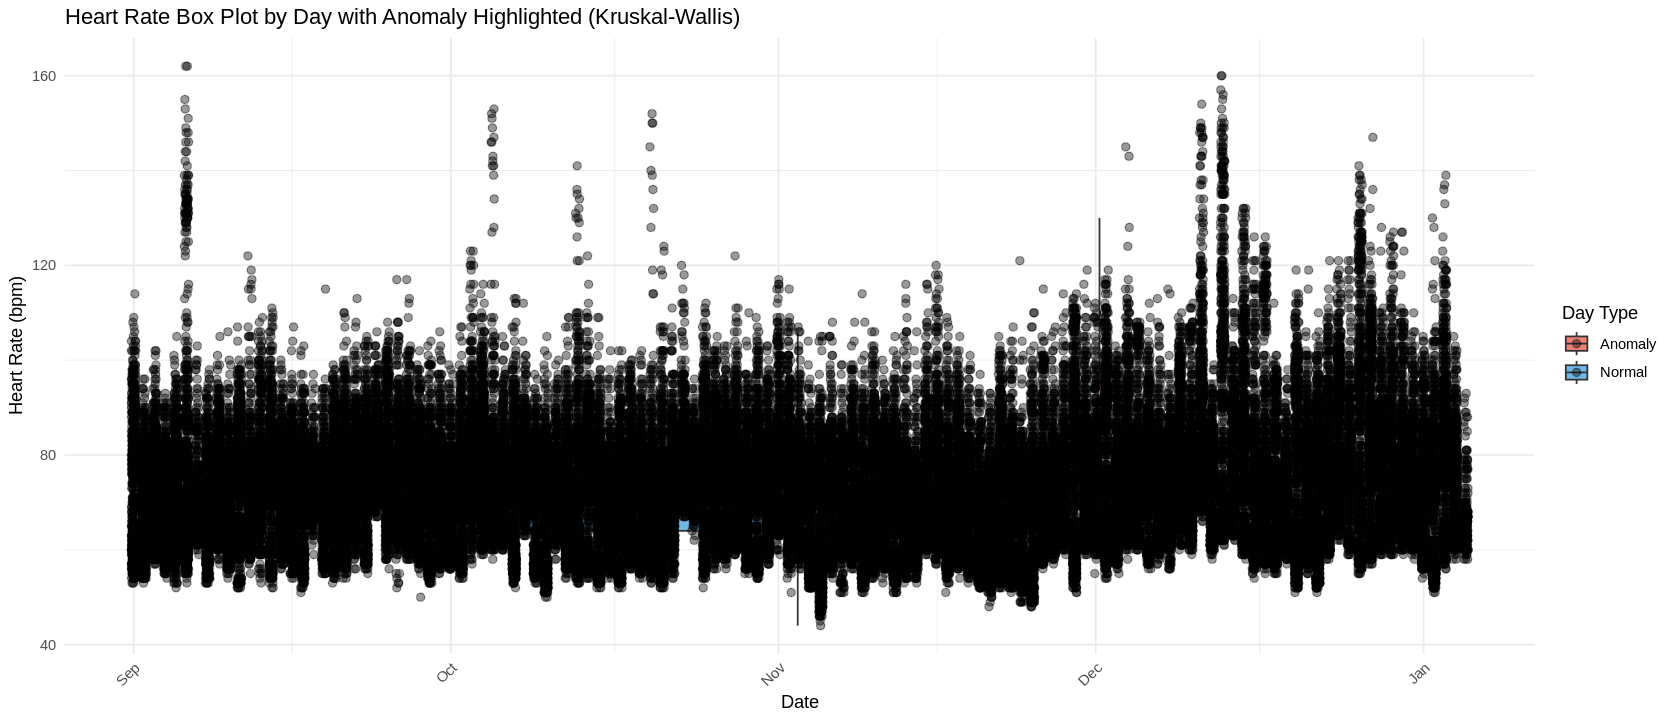

In [89]:
# ================================================================================
# CHUNK 9: Statistical Analysis - Heart Rate Distribution by Date (Kruskal-Wallis Test)
# ================================================================================

# Calculate summary statistics for observed heart rate grouped by calendar date
# Creates quartiles (Q1, Q3), median, min, max, and IQR for each day
statistics <- tab %>%
  group_by(calendarDate) %>%  # Group all observations by their calendar date
  summarise(
    Min = min(observed, na.rm = TRUE),  # Minimum heart rate for the day
    Q1 = quantile(observed, 0.25, na.rm = TRUE),  # First quartile (25th percentile) of heart rate
    Median = median(observed, na.rm = TRUE),  # Median (50th percentile) heart rate
    Q3 = quantile(observed, 0.75, na.rm = TRUE),  # Third quartile (75th percentile) of heart rate
    Max = max(observed, na.rm = TRUE),  # Maximum heart rate for the day
    IQR = IQR(observed, na.rm = TRUE),  # Interquartile range (Q3 - Q1)
    .groups = "drop"  # Drop grouping structure after summarization
  )

# Display summary statistics dataframe with explanation
fx(statistics, "statistics contains quartiles and IQR for heart rate by date")

# Perform Kruskal-Wallis H-test to determine if heart rate distributions differ significantly across days
# Null hypothesis: HR distributions are the same for all days
# Alternative hypothesis: At least one day has a different HR distribution
kruskal <- kruskal.test(observed ~ calendarDate, data = tab)

# Identify the calendar date with the highest median heart rate (potential anomalous day)
anomaly_day <- statistics %>%
  filter(Median == max(Median)) %>%  # Filter to row with maximum median value
  pull(calendarDate)  # Extract the date value as a vector

# Add a color flag to the main dataframe to mark observations from the anomalous day
tab <- tab %>%
  mutate(colorFlag = ifelse(calendarDate == anomaly_day, "Anomaly", "Normal"))  # Flag anomaly day in red, others in blue

# Create ggplot box plot visualization showing heart rate distribution by date
# Box plot displays quartiles, median, and individual points for each day
p <- ggplot(tab, aes(x = calendarDate, y = observed, fill = colorFlag)) +
  geom_boxplot(alpha = 0.7, outlier.shape = NA) +  # Create box plot with transparency, hide outliers from boxplot (shown as points)
  geom_jitter(width = 0.2, height = 0, alpha = 0.4, size = 2) +  # Add jittered points to show individual observations
  scale_fill_manual(values = c("Normal" = "#3498DB", "Anomaly" = "#E74C3C")) +  # Define color mapping for normal and anomaly days
  labs(
    title = "Heart Rate Box Plot by Day with Anomaly Highlighted (Kruskal-Wallis)",  # Plot title
    x = "Date",  # X-axis label
    y = "Heart Rate (bpm)",  # Y-axis label
    fill = "Day Type"  # Legend title
  ) +
  theme_minimal() +  # Apply minimal theme for clean appearance
  theme(axis.text.x = element_text(angle = 45, hjust = 1))  # Rotate date labels for readability

# Display the ggplot in the notebook
print(p)

# Print Kruskal-Wallis test results to console
cat("\nKruskal-Wallis p-value:", kruskal$p.value, "\n")  # Print p-value for statistical significance test
cat("Anomalous day identified:", anomaly_day, "\n")  # Print the date with highest median HR